In [1]:
import torch
import os
import numpy as np
import pandas as pd
import math
import matplotlib.pyplot as plt
import seaborn as sns
import re

In [2]:
root_cub = os.path.join("experiments", "scbm_residual", "CUB")

# # 50 residuals
EXPERIMENT_PATH = os.path.join(root_cub, "Mateo_025_fixed_emp_perc_L_int_extension_loss_weight_1_2026-07-30_17-04-11_72f02")

# # 20 residuals
# EXPERIMENT_PATH = os.path.join(root_cub, "Mateo_025_fixed_emp_perc_residuals_20_L_int_extension_loss_weight_1_2026-07-31_20-15-47_174e5")

# 5 residuals
# EXPERIMENT_PATH = os.path.join(root_cub, "Mateo_025_fixed_emp_perc_residuals_5_L_int_extension_loss_weight_1_2026-07-31_20-15-47_496cf")



In [3]:
# Get class names
with open(os.path.join("datasets","CUB","CUB_200_2011","CUB_200_2011","classes.txt"),"r") as f:
    class_names_names = [line.strip().split(" ")[1] for line in f.readlines()]
    
class_names_names

['001.Black_footed_Albatross',
 '002.Laysan_Albatross',
 '003.Sooty_Albatross',
 '004.Groove_billed_Ani',
 '005.Crested_Auklet',
 '006.Least_Auklet',
 '007.Parakeet_Auklet',
 '008.Rhinoceros_Auklet',
 '009.Brewer_Blackbird',
 '010.Red_winged_Blackbird',
 '011.Rusty_Blackbird',
 '012.Yellow_headed_Blackbird',
 '013.Bobolink',
 '014.Indigo_Bunting',
 '015.Lazuli_Bunting',
 '016.Painted_Bunting',
 '017.Cardinal',
 '018.Spotted_Catbird',
 '019.Gray_Catbird',
 '020.Yellow_breasted_Chat',
 '021.Eastern_Towhee',
 '022.Chuck_will_Widow',
 '023.Brandt_Cormorant',
 '024.Red_faced_Cormorant',
 '025.Pelagic_Cormorant',
 '026.Bronzed_Cowbird',
 '027.Shiny_Cowbird',
 '028.Brown_Creeper',
 '029.American_Crow',
 '030.Fish_Crow',
 '031.Black_billed_Cuckoo',
 '032.Mangrove_Cuckoo',
 '033.Yellow_billed_Cuckoo',
 '034.Gray_crowned_Rosy_Finch',
 '035.Purple_Finch',
 '036.Northern_Flicker',
 '037.Acadian_Flycatcher',
 '038.Great_Crested_Flycatcher',
 '039.Least_Flycatcher',
 '040.Olive_sided_Flycatcher',
 '

## Model Performance

In [4]:
# Give accuracy per class
y_test_true = torch.load(os.path.join(EXPERIMENT_PATH, "test", "y_true.pt"))
y_test_pred_logits = torch.load(os.path.join(EXPERIMENT_PATH, "test", "y_pred.pt"))

# Convert logits to predictions
y_test_pred = torch.argmax(y_test_pred_logits, dim=1)


# Get accuracy for each class
num_classes = len(class_names_names)
class_correct = [0] * num_classes
class_total = [0] * num_classes 

for i in range(num_classes):
    class_mask = (y_test_true == i)
    class_correct[i] = (y_test_pred[class_mask] == y_test_true[class_mask]).sum().item()
    class_total[i] = class_mask.sum().item()
    
# Create dataframe with num_samples per class, class_name, class_idx, accuracy



class_wise_performance_df = pd.DataFrame({
    "class_idx": list(range(num_classes)),
    "class_name": class_names_names,
    "num_samples": class_total,
    "accuracy": [class_correct[i] / class_total[i] if class_total[i] > 0 else 0 for i in range(num_classes)]
})

class_wise_performance_df.head(200)


,class_idx,class_name,num_samples,accuracy
0,0,001.Black_footed_Albatross,30,0.700000
1,1,002.Laysan_Albatross,30,0.533333
2,2,003.Sooty_Albatross,28,0.678571
3,3,004.Groove_billed_Ani,30,0.533333
4,4,005.Crested_Auklet,14,0.642857
...,...,...,...,...
195,195,196.House_Wren,30,0.666667
196,196,197.Marsh_Wren,30,0.633333
197,197,198.Rock_Wren,30,0.633333
198,198,199.Winter_Wren,30,0.833333


Per-class accuracy over 200 classes: mean 68.2%, median 72.4%, min 10.0%, max 100.0%


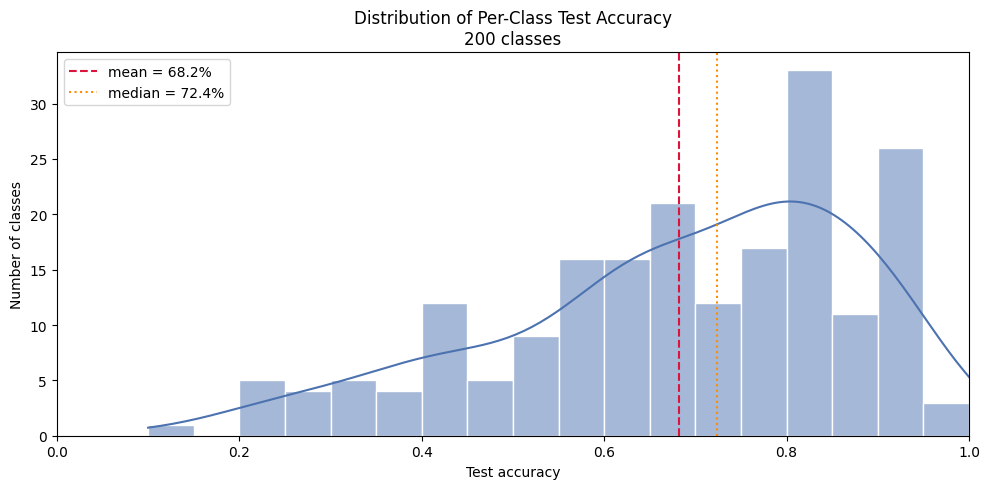

In [5]:
# ============================================================
# Distribution of per-class test accuracy
# ============================================================

accuracies = class_wise_performance_df["accuracy"]

mean_accuracy = accuracies.mean()
median_accuracy = accuracies.median()


print(
    f"Per-class accuracy over {len(accuracies)} classes: "
    f"mean {mean_accuracy:.1%}, "
    f"median {median_accuracy:.1%}, "
    f"min {accuracies.min():.1%}, "
    f"max {accuracies.max():.1%}"
)


plt.figure(figsize=(10, 5))

ax = sns.histplot(
    accuracies,
    bins=20,
    binrange=(0, 1),
    kde=True,
    color="#4C72B0",
    edgecolor="white",
)

ax.axvline(
    mean_accuracy,
    color="crimson",
    linestyle="--",
    label=f"mean = {mean_accuracy:.1%}",
)

ax.axvline(
    median_accuracy,
    color="darkorange",
    linestyle=":",
    label=f"median = {median_accuracy:.1%}",
)

ax.set_xlim(0, 1)
ax.set_xlabel("Test accuracy")
ax.set_ylabel("Number of classes")

ax.set_title(
    "Distribution of Per-Class Test Accuracy\n"
    f"{len(accuracies)} classes"
)

ax.legend()

plt.tight_layout()
plt.show()


In [6]:
# Give top 5 lowest accuracy classes
top_5_lowest_accuracy_classes_df = class_wise_performance_df.sort_values(by="accuracy").head(5)
top_5_lowest_accuracy_classes_df

,class_idx,class_name,num_samples,accuracy
143,143,144.Common_Tern,30,0.100000
65,65,066.Western_Gull,30,0.200000
61,61,062.Herring_Gull,30,0.200000
101,101,102.Western_Wood_Pewee,30,0.200000
29,29,030.Fish_Crow,30,0.233333


## Dataset information

In [7]:
ATTRIBUTES_IDX_USED = [1, 4, 6, 7, 10, 14, 15, 20, 21, 23, 25, 29, 30, 35, 36, 38, 40, 44, 45, 50, 51, 53, 54, 56, 57, 59, 63, 64, 69, 70, 72, 75, 80, 84, 90, 91, \
    93, 99, 101, 106, 110, 111, 116, 117, 119, 125, 126, 131, 132, 134, 145, 149, 151, 152, 153, 157, 158, 163, 164, 168, 172, 178, 179, 181, \
    183, 187, 188, 193, 194, 196, 198, 202, 203, 208, 209, 211, 212, 213, 218, 220, 221, 225, 235, 236, 238, 239, 240, 242, 243, 244, 249, 253, \
    254, 259, 260, 262, 268, 274, 277, 283, 289, 292, 293, 294, 298, 299, 304, 305, 308, 309, 310, 311]

with open(os.path.join("datasets", "CUB", "CUB_200_2011", "attributes.txt"), 'r') as f:
    all_attributes_orig_idx = {}
    
    lines = f.readlines()
    for line in lines:
        idx, attr_name = line.strip().split(" ")
        #attr_group, attr_name = attr_name.split("::")  
        # 0-based indexing
        all_attributes_orig_idx[int(idx) - 1] = attr_name
  
# Map between 112 concept idx and attribute name      
sample_112_concepts_map = {new_idx: all_attributes_orig_idx[orig_idx] for new_idx, orig_idx in enumerate(ATTRIBUTES_IDX_USED)}
attr_groups__112_concepts = list(set(attr_name.split("::")[0] for attr_name in sample_112_concepts_map.values()))

print(sample_112_concepts_map)
print(attr_groups__112_concepts)
print(len(attr_groups__112_concepts))


{0: 'has_bill_shape::dagger', 1: 'has_bill_shape::hooked_seabird', 2: 'has_bill_shape::all-purpose', 3: 'has_bill_shape::cone', 4: 'has_wing_color::brown', 5: 'has_wing_color::grey', 6: 'has_wing_color::yellow', 7: 'has_wing_color::black', 8: 'has_wing_color::white', 9: 'has_wing_color::buff', 10: 'has_upperparts_color::brown', 11: 'has_upperparts_color::grey', 12: 'has_upperparts_color::yellow', 13: 'has_upperparts_color::black', 14: 'has_upperparts_color::white', 15: 'has_upperparts_color::buff', 16: 'has_underparts_color::brown', 17: 'has_underparts_color::grey', 18: 'has_underparts_color::yellow', 19: 'has_underparts_color::black', 20: 'has_underparts_color::white', 21: 'has_underparts_color::buff', 22: 'has_breast_pattern::solid', 23: 'has_breast_pattern::striped', 24: 'has_breast_pattern::multi-colored', 25: 'has_back_color::brown', 26: 'has_back_color::grey', 27: 'has_back_color::yellow', 28: 'has_back_color::black', 29: 'has_back_color::white', 30: 'has_back_color::buff', 31: '

In [8]:
# Read dataset dir from the log file in the experiment path
import ast


info_dataset_path = os.path.join("datasets", "CUB", "incomplete_data", "Mateo_025", "info.txt")


with open(info_dataset_path, 'r') as f:
    lines = f.readlines()

    for line in lines:
        if "New attribute indices mapping: " in line:
            new_attribute_mapping_string = line.split("New attribute indices mapping: ")[1].strip()
            
        if "Removed attribute groups: " in line:
            removed_attribute_groups_string = line.split("Removed attribute groups: ")[1].strip()
            

# Original has 112 attributes, but we only use a subset of them
new_attribute_mapping = ast.literal_eval(new_attribute_mapping_string)

# Removed groups list
removed_attribute_groups = ast.literal_eval(removed_attribute_groups_string)
    

        
        
concept_names_new_idx_map = {}
for orig_idx, new_idx in new_attribute_mapping.items():
    concept_names_new_idx_map[new_idx] = sample_112_concepts_map[orig_idx]


df = pd.DataFrame(list(concept_names_new_idx_map.items()), columns=['New Index', 'Concept Name'])
df.to_csv("delete_afterwards/concept_names_new_idx_map.csv", index=False)
display(df.sort_values(by='New Index').reset_index(drop=True))

# Number of attrbutes removed
print(f"Number of attributes removed: {112 - len(concept_names_new_idx_map.keys())}")





,New Index,Concept Name
0,0,has_bill_shape::dagger
1,1,has_bill_shape::hooked_seabird
2,2,has_bill_shape::all-purpose
3,3,has_bill_shape::cone
4,4,has_head_pattern::eyebrow
5,5,has_head_pattern::plain
6,6,has_breast_color::brown
7,7,has_breast_color::grey
8,8,has_breast_color::yellow
9,9,has_breast_color::black


Number of attributes removed: 90


### Check that the attribute groups in the above df is the same as the attribute groups kept for data generation

This is a security check


In [9]:
# Check if the concept name in the df matches the attribute groups that were used: attr_groups_unique
attr_groups_from_df = df["Concept Name"].apply(lambda name: name.split("::")[0])

attr_groups_from_df = list(attr_groups_from_df.unique())


kept_attr_groups_from_info = [group for group in attr_groups__112_concepts if group not in removed_attribute_groups]

# Check if the kept attribute groups from the info file match the attribute groups from the df
print(f"same attribute groups: {set(kept_attr_groups_from_info) == set(attr_groups_from_df)}")


same attribute groups: True


### Missing concepts 

In [10]:
missing_concept_names = [sample_112_concepts_map[orig_idx] for orig_idx in range(112) if orig_idx not in new_attribute_mapping.keys()]
print(missing_concept_names)

['has_wing_color::brown', 'has_wing_color::grey', 'has_wing_color::yellow', 'has_wing_color::black', 'has_wing_color::white', 'has_wing_color::buff', 'has_upperparts_color::brown', 'has_upperparts_color::grey', 'has_upperparts_color::yellow', 'has_upperparts_color::black', 'has_upperparts_color::white', 'has_upperparts_color::buff', 'has_underparts_color::brown', 'has_underparts_color::grey', 'has_underparts_color::yellow', 'has_underparts_color::black', 'has_underparts_color::white', 'has_underparts_color::buff', 'has_breast_pattern::solid', 'has_breast_pattern::striped', 'has_breast_pattern::multi-colored', 'has_back_color::brown', 'has_back_color::grey', 'has_back_color::yellow', 'has_back_color::black', 'has_back_color::white', 'has_back_color::buff', 'has_tail_shape::notched_tail', 'has_upper_tail_color::brown', 'has_upper_tail_color::grey', 'has_upper_tail_color::black', 'has_upper_tail_color::white', 'has_upper_tail_color::buff', 'has_throat_color::grey', 'has_throat_color::yell

## Check mean of residuals

In [36]:
train_probs = torch.load(os.path.join(EXPERIMENT_PATH, "train", "concepts_residuals_pred_probs_mean.pt"))
val_probs = torch.load(os.path.join(EXPERIMENT_PATH, "val", "concepts_residuals_pred_probs_mean.pt"))
test_probs = torch.load(os.path.join(EXPERIMENT_PATH, "test", "concepts_residuals_pred_probs_mean.pt"))

In [37]:
base_train = train_probs[:, C:].mean(0)
base_val   = val_probs[:, C:].mean(0)
base_test  = test_probs[:, C:].mean(0)
print((base_train - base_val).abs().max(), (base_val - base_test).abs().max())

tensor(0.0504) tensor(0.0207)


## Most activated samples in test set for different residuals

In [11]:
scbm_res_model = torch.load(os.path.join(EXPERIMENT_PATH, "model.pth"), map_location="cpu")

# What's in there
for k, v in scbm_res_model.items():
    if k.startswith("head"):
        print(k, tuple(v.shape))

# Last linear layer of the head (head.0 for linear head, head.2 for the MLP head)
head_idx = max(int(re.match(r"head\.(\d+)\.weight", k).group(1))
               for k in scbm_res_model if re.match(r"head\.\d+\.weight", k))
W = scbm_res_model[f"head.{head_idx}.weight"]        # [pred_dim, num_concepts + num_residuals]
b = scbm_res_model[f"head.{head_idx}.bias"]          # [pred_dim]
print(f"head.{head_idx}: W {tuple(W.shape)}, b {tuple(b.shape)}")


print(W.shape)

head.0.weight (200, 72)
head.0.bias (200,)
head.0: W (200, 72), b (200,)
torch.Size([200, 72])


### Most important residuals per sample

In [12]:
import os
import re
import torch


# ============================================================
# 1. Load and verify the linear prediction head
# ============================================================

checkpoint = torch.load(
    os.path.join(EXPERIMENT_PATH, "model.pth"),
    map_location="cpu",
)

# Support checkpoints saved either directly as a state_dict
# or inside a "state_dict" entry.
if (
    isinstance(checkpoint, dict)
    and "state_dict" in checkpoint
    and isinstance(checkpoint["state_dict"], dict)
):
    scbm_res_model = checkpoint["state_dict"]
else:
    scbm_res_model = checkpoint


# Print all head parameters.
for key, value in scbm_res_model.items():
    if key.startswith("head"):
        print(key, tuple(value.shape))


# Find linear layers in the prediction head.
head_weight_keys = [
    key
    for key in scbm_res_model
    if re.fullmatch(r"head\.\d+\.weight", key)
]

if len(head_weight_keys) == 0:
    raise ValueError("No linear prediction-head weights were found.")


# This analysis assumes that the selected layer directly maps
# [concepts, residuals] to class logits.
head_idx = max(
    int(
        re.fullmatch(
            r"head\.(\d+)\.weight",
            key,
        ).group(1)
    )
    for key in head_weight_keys
)

W = scbm_res_model[
    f"head.{head_idx}.weight"
].detach().float()

b = scbm_res_model[
    f"head.{head_idx}.bias"
].detach().float()

print(
    f"head.{head_idx}: "
    f"W {tuple(W.shape)}, "
    f"b {tuple(b.shape)}"
)


# Bottleneck dimensions.
C = NUM_CONCEPTS = 22
R = NUM_RESIDUALS = W.shape[1] - C

if R <= 0:
    raise ValueError(
        f"Invalid residual dimension R={R}. "
        f"Head input dimension={W.shape[1]}, C={C}."
    )

print(f"Number of concepts: {C}")
print(f"Number of residuals: {R}")


# Split the prediction-head weights.
W_c = W[:, :C]   # [K, C]
W_r = W[:, C:]   # [K, R]

assert W_c.shape[1] == C
assert W_r.shape[1] == R
assert W.shape[1] == C + R


# ============================================================
# 2. Convert prediction logits to class probabilities
# ============================================================

y_pred_logits = torch.load(
    os.path.join(
        EXPERIMENT_PATH,
        "test",
        "y_pred.pt",
    ),
    map_location="cpu",
).float()

y_true = torch.load(
    os.path.join(
        EXPERIMENT_PATH,
        "test",
        "y_true.pt",
    ),
    map_location="cpu",
).long().view(-1)


if y_pred_logits.ndim != 2:
    raise ValueError(
        "Expected y_pred logits to have shape [N, K], "
        f"but received {tuple(y_pred_logits.shape)}."
    )

num_samples, num_classes = y_pred_logits.shape

assert W.shape[0] == num_classes, (
    f"The head has {W.shape[0]} output classes, but "
    f"y_pred has {num_classes} classes."
)

assert y_true.shape[0] == num_samples, (
    "The number of labels does not match the number "
    "of prediction samples."
)


# Convert raw class logits into probabilities.
p_bar = torch.softmax(
    y_pred_logits,
    dim=1,
)

# Aggregated predicted class.
top1_class = y_pred_logits.argmax(dim=1)

assert p_bar.shape == y_pred_logits.shape
assert torch.allclose(
    p_bar.sum(dim=1),
    torch.ones_like(p_bar.sum(dim=1)),
    atol=1e-6,
)

print(
    "y_pred_logits.shape:",
    tuple(y_pred_logits.shape),
)

print(
    "p_bar.shape:",
    tuple(p_bar.shape),
)

print(
    "top1_class.shape:",
    tuple(top1_class.shape),
)


# ============================================================
# 3. Load Rao-Blackwellized MC activation probabilities
# ============================================================

train_probs_path = os.path.join(
    EXPERIMENT_PATH,
    "train",
    "concepts_residuals_pred_probs_mean.pt",
)

test_probs_path = os.path.join(
    EXPERIMENT_PATH,
    "test",
    "concepts_residuals_pred_probs_mean.pt",
)


train_pred_probs_mean = torch.load(
    train_probs_path,
    map_location="cpu",
).float()

test_pred_probs_mean = torch.load(
    test_probs_path,
    map_location="cpu",
).float()


if train_pred_probs_mean.ndim != 2:
    raise ValueError(
        "Expected train activation probabilities to have "
        f"shape [N_train, C + R], but received "
        f"{tuple(train_pred_probs_mean.shape)}."
    )

if test_pred_probs_mean.ndim != 2:
    raise ValueError(
        "Expected test activation probabilities to have "
        f"shape [N_test, C + R], but received "
        f"{tuple(test_pred_probs_mean.shape)}."
    )

assert train_pred_probs_mean.shape[1] == C + R, (
    f"Train activation tensor has "
    f"{train_pred_probs_mean.shape[1]} dimensions, "
    f"but expected {C + R}."
)

assert test_pred_probs_mean.shape[1] == C + R, (
    f"Test activation tensor has "
    f"{test_pred_probs_mean.shape[1]} dimensions, "
    f"but expected {C + R}."
)

assert test_pred_probs_mean.shape[0] == num_samples, (
    "The number of test activation samples does not "
    "match the number of prediction samples."
)


# MC-averaged activation probabilities:
#
#   p_mean[n, j]
#       = (1/M) sum_m sigmoid(eta[n, j, m])
#
train_c_prob_mean = train_pred_probs_mean[:, :C]
train_r_prob_mean = train_pred_probs_mean[:, C:]

test_c_prob_mean = test_pred_probs_mean[:, :C]
test_r_prob_mean = test_pred_probs_mean[:, C:]


print(
    "train_c_prob_mean.shape:",
    tuple(train_c_prob_mean.shape),
)

print(
    "train_r_prob_mean.shape:",
    tuple(train_r_prob_mean.shape),
)

print(
    "test_c_prob_mean.shape:",
    tuple(test_c_prob_mean.shape),
)

print(
    "test_r_prob_mean.shape:",
    tuple(test_r_prob_mean.shape),
)


# ============================================================
# 4. Compute train-set activation baselines
# ============================================================

# Population-average activation probability for each dimension.
c_train_base_rate = train_c_prob_mean.mean(dim=0)
r_train_base_rate = train_r_prob_mean.mean(dim=0)


# Center the test activations using train-set statistics.
centered_c = (
    test_c_prob_mean
    - c_train_base_rate.unsqueeze(0)
)

centered_r = (
    test_r_prob_mean
    - r_train_base_rate.unsqueeze(0)
)


assert centered_c.shape == (num_samples, C)
assert centered_r.shape == (num_samples, R)

print(
    "centered_c.shape:",
    tuple(centered_c.shape),
)

print(
    "centered_r.shape:",
    tuple(centered_r.shape),
)


# ============================================================
# 5. Compute probability-weighted class contrasts
# ============================================================

# Weight vectors for the predicted class:
#
#   W_top1[n, :]
#       = W[k*_n, :]
#
W_c_top1 = W_c[top1_class]  # [N, C]
W_r_top1 = W_r[top1_class]  # [N, R]


# Probability-weighted average class weights:
#
#   E_p[W_c][n, i]
#       = sum_k p_bar[n, k] W_c[k, i]
#
#   E_p[W_r][n, j]
#       = sum_k p_bar[n, k] W_r[k, j]
#
expected_W_c = p_bar @ W_c  # [N, C]
expected_W_r = p_bar @ W_r  # [N, R]


# Probability-weighted class contrasts:
#
#   u_c[n, i]
#       = W_c[k*_n, i] - sum_k p[n, k] W_c[k, i]
#
#   u_r[n, j]
#       = W_r[k*_n, j] - sum_k p[n, k] W_r[k, j]
#
u_c = W_c_top1 - expected_W_c
u_r = W_r_top1 - expected_W_r


assert u_c.shape == centered_c.shape
assert u_r.shape == centered_r.shape

print(
    "u_c.shape:",
    tuple(u_c.shape),
)

print(
    "u_r.shape:",
    tuple(u_r.shape),
)


# ============================================================
# 6. Per-sample, per-dimension centered contributions
# ============================================================

# Concept contribution:
#
#   phi_c[n, i]
#       = u_c[n, i]
#         * (c_mean[n, i] - c_train_base[i])
#
phi_c = u_c * centered_c


# Residual contribution:
#
#   phi_r[n, j]
#       = u_r[n, j]
#         * (r_mean[n, j] - r_train_base[j])
#
phi_r = u_r * centered_r

# Residuals are ranked by the SIGNED contribution:
#
#   rank 1 = most positive contribution to the predicted class
#
# |phi_r| is kept only as a magnitude statistic and as the
# normalizer of the per-sample shares below.
signed_phi_r = phi_r
abs_phi_r = phi_r.abs()

# ============================================================
# Per-sample residual contribution shares
# ============================================================

# For each sample, normalize the SIGNED residual contributions
# by the total residual mass of that sample:
#
#   share[n, j] = phi_r[n, j] / sum_j' |phi_r[n, j']|
#
# The sign is kept, so each share lies in [-1, 1] and |share|
# sums to 1 across residual dimensions. The denominator is
# constant within a sample, so ordering residuals by share is
# the same as ordering them by signed contribution.
residual_contribution_share = (
    signed_phi_r
    / abs_phi_r.sum(dim=1, keepdim=True).clamp_min(1e-12)
)

assert residual_contribution_share.shape == (num_samples, R)

print(
    "residual_contribution_share.shape:",
    tuple(residual_contribution_share.shape),
)

print(
    "Mean row sum of |share|:",
    residual_contribution_share.abs().sum(dim=1).mean().item(),
)









assert phi_c.shape == (num_samples, C)
assert phi_r.shape == (num_samples, R)

print(
    "phi_c.shape:",
    tuple(phi_c.shape),
)

print(
    "phi_r.shape:",
    tuple(phi_r.shape),
)


# ============================================================
# 7. Most important residuals for each sample
# ============================================================
#
# Importance is the SIGNED contribution, so the top residuals
# are the ones pushing hardest towards the predicted class.

num_top_residuals = min(5, R)

top_residuals = torch.topk(
    signed_phi_r,
    k=num_top_residuals,
    dim=1,
    largest=True,
)

top_residual_indices = top_residuals.indices
top_residual_signed_contributions = top_residuals.values


# Magnitude of each selected residual, kept for reference.
top_residual_abs_contributions = torch.gather(
    abs_phi_r,
    dim=1,
    index=top_residual_indices,
)


# Activation deviation for each selected residual.
top_residual_activation_deviations = torch.gather(
    centered_r,
    dim=1,
    index=top_residual_indices,
)


# Probability-weighted class contrast for each selected residual.
top_residual_weighted_contrasts = torch.gather(
    u_r,
    dim=1,
    index=top_residual_indices,
)


sample_idx = 1

print(f"\nExample: test sample {sample_idx}")
print(
    "True class:",
    y_true[sample_idx].item(),
)
print(
    "Predicted class:",
    top1_class[sample_idx].item(),
)
print(
    "Predicted probability:",
    p_bar[
        sample_idx,
        top1_class[sample_idx],
    ].item(),
)


for rank in range(num_top_residuals):
    residual_idx = top_residual_indices[
        sample_idx,
        rank,
    ].item()

    contribution = top_residual_signed_contributions[
        sample_idx,
        rank,
    ].item()

    absolute_contribution = top_residual_abs_contributions[
        sample_idx,
        rank,
    ].item()

    weighted_contrast = top_residual_weighted_contrasts[
        sample_idx,
        rank,
    ].item()

    activation_deviation = top_residual_activation_deviations[
        sample_idx,
        rank,
    ].item()

    print(
        f"Rank {rank + 1}: "
        f"residual {residual_idx} | "
        f"contribution={contribution:.6f} | "
        f"|contribution|={absolute_contribution:.6f} | "
        f"weighted contrast={weighted_contrast:.6f} | "
        f"activation deviation={activation_deviation:.6f}"
    )

head.0.weight (200, 72)
head.0.bias (200,)
head.0: W (200, 72), b (200,)
Number of concepts: 22
Number of residuals: 50
y_pred_logits.shape: (5794, 200)
p_bar.shape: (5794, 200)
top1_class.shape: (5794,)
train_c_prob_mean.shape: (4796, 22)
train_r_prob_mean.shape: (4796, 50)
test_c_prob_mean.shape: (5794, 22)
test_r_prob_mean.shape: (5794, 50)
centered_c.shape: (5794, 22)
centered_r.shape: (5794, 50)
u_c.shape: (5794, 22)
u_r.shape: (5794, 50)
residual_contribution_share.shape: (5794, 50)
Mean row sum of |share|: 1.0
phi_c.shape: (5794, 22)
phi_r.shape: (5794, 50)

Example: test sample 1
True class: 0
Predicted class: 0
Predicted probability: 0.6669815182685852
Rank 1: residual 32 | contribution=0.072763 | |contribution|=0.072763 | weighted contrast=-0.132059 | activation deviation=-0.550991
Rank 2: residual 25 | contribution=0.067880 | |contribution|=0.067880 | weighted contrast=-0.118897 | activation deviation=-0.570916
Rank 3: residual 7 | contribution=0.060440 | |contribution|=0.06

### Per class contribution (non-normalized within class)

In [13]:
# ============================================================
# 8. Per-class residual contribution
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import torch


# Ensure labels have shape [N] and are on the same device as phi_r.
y_true = y_true.to(phi_r.device).long().view(-1)

num_samples = phi_r.shape[0]
num_classes = W.shape[0]

assert y_true.shape[0] == num_samples, (
    f"y_true contains {y_true.shape[0]} samples, "
    f"but phi_r contains {num_samples}."
)

assert top1_class.shape[0] == num_samples

assert phi_r.shape == (num_samples, R), (
    f"Expected phi_r shape {(num_samples, R)}, "
    f"but received {tuple(phi_r.shape)}."
)

assert centered_r.shape == (num_samples, R)
assert residual_contribution_share.shape == (num_samples, R)

assert y_true.min() >= 0
assert y_true.max() < num_classes


# ------------------------------------------------------------
# A. Per-class statistics using true-class membership
# ------------------------------------------------------------

# Magnitude statistic, kept for reference. This is NOT the
# ranking criterion:
#
# A[c, j] = mean_{n: y_n = c} |phi_r[n, j]|
per_class_mean_abs_contribution = torch.full(
    (num_classes, R),
    float("nan"),
    dtype=phi_r.dtype,
    device=phi_r.device,
)

# Scale-free companion to the signed measure below:
#
# S[c, j] = mean_{n: y_n = c} residual_contribution_share[n, j]
#         = mean_{n: y_n = c} phi_r[n, j] / sum_j' |phi_r[n, j']|
#
# Each sample contributes equally regardless of how large its
# total residual contribution is, so this reports how the
# residual channel is *allocated* within the class rather than
# how much residual signal the class carries in absolute terms.
# The share keeps its sign, so a class whose samples push the
# same residual in opposite directions averages towards zero.
per_class_mean_contribution_share = torch.full(
    (num_classes, R),
    float("nan"),
    dtype=residual_contribution_share.dtype,
    device=residual_contribution_share.device,
)

# Spread of that share across the samples of the class:
#
# std_{n: y_n = c} residual_contribution_share[n, j]
#
# A small std means the class allocates its residual channel the
# same way for every member; a large std means the mean share is
# an average over samples that disagree.
per_class_std_contribution_share = torch.full(
    (num_classes, R),
    float("nan"),
    dtype=residual_contribution_share.dtype,
    device=residual_contribution_share.device,
)

# Main importance measure (the ranking criterion):
#
# I[c, j] = mean_{n: y_n = c} phi_r[n, j]
per_class_mean_signed_contribution = torch.full(
    (num_classes, R),
    float("nan"),
    dtype=phi_r.dtype,
    device=phi_r.device,
)

# Mean magnitude of the centered activation:
#
# mean_{n: y_n = c} |r_bar[n, j] - r_train_base[j]|
per_class_mean_abs_activation_deviation = torch.full(
    (num_classes, R),
    float("nan"),
    dtype=centered_r.dtype,
    device=centered_r.device,
)

# Mean signed centered activation:
#
# mean_{n: y_n = c} (r_bar[n, j] - r_train_base[j])
per_class_mean_activation_deviation = torch.full(
    (num_classes, R),
    float("nan"),
    dtype=centered_r.dtype,
    device=centered_r.device,
)

num_samples_per_class = torch.zeros(
    num_classes,
    dtype=torch.long,
    device=phi_r.device,
)


for class_idx in range(num_classes):
    class_mask = y_true == class_idx
    class_count = int(class_mask.sum().item())

    num_samples_per_class[class_idx] = class_count

    if class_count == 0:
        continue

    class_phi_r = phi_r[class_mask]          # [N_c, R]
    class_share = residual_contribution_share[class_mask]  # [N_c, R]
    # centered_r = r_bar - r_train_base = r_bar - mean(r_bar) for train set where r_bar = r_pred_probs_mean
    class_centered_r = centered_r[class_mask]  # [N_c, R]

    per_class_mean_abs_contribution[class_idx] = (
        class_phi_r.abs().mean(dim=0)
    )

    per_class_mean_contribution_share[class_idx] = (
        class_share.mean(dim=0)
    )

    # Population standard deviation across the samples of the
    # class. correction=0 also works when the class has one
    # sample, matching the convention used for the rank spreads.
    per_class_std_contribution_share[class_idx] = (
        class_share.std(
            dim=0,
            correction=0,
        )
    )

    per_class_mean_signed_contribution[class_idx] = (
        class_phi_r.mean(dim=0)
    )

    per_class_mean_abs_activation_deviation[class_idx] = (
        class_centered_r.abs().mean(dim=0)
    )

    per_class_mean_activation_deviation[class_idx] = (
        class_centered_r.mean(dim=0)
    )


print(
    "per_class_mean_abs_contribution.shape:",
    tuple(per_class_mean_abs_contribution.shape),
)

print(
    "per_class_mean_contribution_share.shape:",
    tuple(per_class_mean_contribution_share.shape),
)

print(
    "per_class_std_contribution_share.shape:",
    tuple(per_class_std_contribution_share.shape),
)

print(
    "Number of samples per class:",
    num_samples_per_class.detach().cpu().tolist(),
)



per_class_mean_abs_contribution.shape: (200, 50)
per_class_mean_contribution_share.shape: (200, 50)
per_class_std_contribution_share.shape: (200, 50)
Number of samples per class: [30, 30, 28, 30, 14, 11, 23, 18, 29, 30, 30, 26, 30, 30, 28, 28, 27, 15, 29, 29, 30, 26, 29, 22, 30, 30, 30, 29, 30, 30, 30, 23, 29, 29, 30, 30, 29, 30, 29, 30, 30, 30, 29, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 28, 30, 29, 30, 30, 30, 30, 20, 30, 30, 30, 30, 30, 30, 30, 30, 30, 27, 30, 30, 29, 30, 30, 30, 30, 30, 23, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 29, 30, 30, 30, 20, 30, 30, 30, 19, 30, 30, 30, 30, 30, 30, 30, 20, 30, 29, 30, 29, 30, 29, 30, 30, 30, 30, 29, 29, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 29, 30, 30, 30, 30, 30, 30, 30, 29, 30, 21, 30, 29, 30, 30, 30, 29, 30, 30, 29, 30, 30, 30, 30, 30, 29, 30, 29, 29, 30, 30, 30, 30, 30, 30, 30, 30, 26, 29, 30, 29, 30, 30, 30, 30, 30, 20, 30, 30, 29, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30]


In [14]:
# ============================================================
# Get mean and std rank of residual importance per class
# ============================================================

import numpy as np
import torch
from scipy.stats import rankdata


# Ensure labels are one-dimensional and on the same device.
y_true = y_true.to(phi_r.device).long().view(-1)

num_samples, num_residuals = phi_r.shape
num_classes = W.shape[0]

assert num_residuals == R, (
    f"phi_r has {num_residuals} residual dimensions, "
    f"but R={R}."
)

assert y_true.shape[0] == num_samples, (
    f"y_true has {y_true.shape[0]} samples, "
    f"but phi_r has {num_samples}."
)

assert top1_class.shape[0] == num_samples

assert y_true.min().item() >= 0
assert y_true.max().item() < num_classes


# ------------------------------------------------------------
# 1. Rank residuals for every sample
# ------------------------------------------------------------

# Rank according to the SIGNED contribution:
#
# rank 1 = most positive contribution
# rank R = most negative contribution
signed_phi_r = phi_r  # [N, R]


# Use average ranks for ties.
#
# Example:
# contributions = [0.8, 0.4, 0.4, -0.1]
# ranks         = [1.0, 2.5, 2.5,  4.0]
#
# The negative sign is used because scipy.rankdata assigns
# rank 1 to the smallest value by default.
signed_phi_r_np = signed_phi_r.detach().cpu().numpy()

per_sample_residual_ranks_np = np.apply_along_axis(
    lambda row: rankdata(
        -row,
        method="average",
    ),
    axis=1,
    arr=signed_phi_r_np,
)

per_sample_residual_ranks = torch.from_numpy(
    per_sample_residual_ranks_np
).to(
    device=phi_r.device,
    dtype=phi_r.dtype,
)


assert per_sample_residual_ranks.shape == (num_samples, R)

print(
    "per_sample_residual_ranks.shape:",
    tuple(per_sample_residual_ranks.shape),
)


# ============================================================
# 2. Aggregate ranks within each true class
# ============================================================

per_class_mean_rank = torch.full(
    (num_classes, R),
    float("nan"),
    dtype=phi_r.dtype,
    device=phi_r.device,
)

per_class_std_rank = torch.full(
    (num_classes, R),
    float("nan"),
    dtype=phi_r.dtype,
    device=phi_r.device,
)

per_class_median_rank = torch.full(
    (num_classes, R),
    float("nan"),
    dtype=phi_r.dtype,
    device=phi_r.device,
)

num_samples_per_class = torch.zeros(
    num_classes,
    dtype=torch.long,
    device=phi_r.device,
)


for class_idx in range(num_classes):
    class_mask = y_true == class_idx
    class_count = int(class_mask.sum().item())

    num_samples_per_class[class_idx] = class_count

    if class_count == 0:
        continue

    # Shape: [number of class samples, R]
    class_ranks = per_sample_residual_ranks[class_mask]

    per_class_mean_rank[class_idx] = (
        class_ranks.mean(dim=0)
    )

    # Population standard deviation across samples in the class.
    # correction=0 also works when the class has one sample.
    per_class_std_rank[class_idx] = (
        class_ranks.std(
            dim=0,
            correction=0,
        )
    )

    per_class_median_rank[class_idx] = (
        class_ranks.median(dim=0).values
    )


print(
    "per_class_mean_rank.shape:",
    tuple(per_class_mean_rank.shape),
)

print(
    "per_class_std_rank.shape:",
    tuple(per_class_std_rank.shape),
)

print(
    "per_class_median_rank.shape:",
    tuple(per_class_median_rank.shape),
)


# ============================================================
# 3. Inspect one class
# ============================================================

class_to_inspect = 1
num_to_show = min(10, R)

if not 0 <= class_to_inspect < num_classes:
    raise ValueError(
        f"class_to_inspect must be between 0 and "
        f"{num_classes - 1}, but received {class_to_inspect}."
    )

class_count = int(
    num_samples_per_class[class_to_inspect].item()
)

if class_count == 0:
    raise ValueError(
        f"Class {class_to_inspect} has no samples."
    )


# Lower mean rank means the residual more consistently
# pushes towards the class.
residual_order = torch.argsort(
    per_class_mean_rank[class_to_inspect],
    descending=False,
)


print(
    f"\nResidual importance ranks for class "
    f"{class_to_inspect} "
    f"(n={class_count}):"
)


for position, residual_idx in enumerate(
    residual_order[:num_to_show],
    start=1,
):
    j = int(residual_idx.item())

    mean_rank = per_class_mean_rank[
        class_to_inspect,
        j,
    ].item()

    std_rank = per_class_std_rank[
        class_to_inspect,
        j,
    ].item()

    median_rank = per_class_median_rank[
        class_to_inspect,
        j,
    ].item()

    mean_signed_contribution = (
        per_class_mean_signed_contribution[
            class_to_inspect,
            j,
        ].item()
    )

    mean_abs_contribution = (
        per_class_mean_abs_contribution[
            class_to_inspect,
            j,
        ].item()
    )

    mean_contribution_share = (
        per_class_mean_contribution_share[
            class_to_inspect,
            j,
        ].item()
    )

    std_contribution_share = (
        per_class_std_contribution_share[
            class_to_inspect,
            j,
        ].item()
    )

    print(
        f"{position:2d}. residual {j:2d} | "
        f"mean rank = {mean_rank:.2f} | "
        f"std rank = {std_rank:.2f} | "
        f"median rank = {median_rank:.2f} | "
        f"mean contribution = "
        f"{mean_signed_contribution:+.6f} | "
        f"mean |contribution| = "
        f"{mean_abs_contribution:.6f} | "
        f"mean share = "
        f"{mean_contribution_share:.4f} | "
        f"std share = "
        f"{std_contribution_share:.4f}"
    )

per_sample_residual_ranks.shape: (5794, 50)
per_class_mean_rank.shape: (200, 50)
per_class_std_rank.shape: (200, 50)
per_class_median_rank.shape: (200, 50)

Residual importance ranks for class 1 (n=30):
 1. residual 27 | mean rank = 8.40 | std rank = 10.06 | median rank = 4.00 | mean contribution = +0.085451 | mean |contribution| = 0.085563 | mean share = 0.0352 | std share = 0.0144
 2. residual 30 | mean rank = 13.17 | std rank = 12.15 | median rank = 8.00 | mean contribution = +0.062881 | mean |contribution| = 0.073804 | mean share = 0.0280 | std share = 0.0184
 3. residual 35 | mean rank = 13.50 | std rank = 14.20 | median rank = 9.00 | mean contribution = +0.067017 | mean |contribution| = 0.083401 | mean share = 0.0275 | std share = 0.0256
 4. residual 24 | mean rank = 14.57 | std rank = 14.61 | median rank = 8.00 | mean contribution = +0.058045 | mean |contribution| = 0.064612 | mean share = 0.0263 | std share = 0.0200
 5. residual 41 | mean rank = 14.93 | std rank = 9.70 | median

In [15]:
# ============================================================
# Per-class residual consistency
# ============================================================

TOP_K_VALUES = [1, 3, 5, 10]

rows = []

for class_idx in range(num_classes):

    class_mask = y_true == class_idx
    n_class = int(class_mask.sum().item())

    if n_class == 0:
        continue

    # Top-k = the k most positive signed contributions.
    class_signed_phi = signed_phi_r[class_mask]  # [N_c, R]

    topk_frequencies = {}

    for k in TOP_K_VALUES:

        topk_idx = torch.topk(
            class_signed_phi,
            k=k,
            dim=1,
            largest=True,
        ).indices

        topk_mask = torch.zeros(
            (n_class, R),
            dtype=torch.bool,
            device=class_signed_phi.device,
        )

        topk_mask.scatter_(1, topk_idx, True)

        topk_frequencies[k] = (
            topk_mask.float().mean(dim=0)
        )

    for residual_idx in range(R):

        rows.append({
            "class_idx": class_idx,
            "class_name": class_names_names[class_idx],
            "num_samples": n_class,
            "residual_idx": residual_idx,

            "mean_rank":
                per_class_mean_rank[
                    class_idx, residual_idx
                ].item(),

            "std_rank":
                per_class_std_rank[
                    class_idx, residual_idx
                ].item(),

            "median_rank":
                per_class_median_rank[
                    class_idx, residual_idx
                ].item(),

            "top1_frequency":
                topk_frequencies[1][residual_idx].item(),

            "top3_frequency":
                topk_frequencies[3][residual_idx].item(),

            "top5_frequency":
                topk_frequencies[5][residual_idx].item(),

            "top10_frequency":
                topk_frequencies[10][residual_idx].item(),
        })

residual_consistency_df = pd.DataFrame(rows)

residual_consistency_df

,class_idx,class_name,num_samples,residual_idx,mean_rank,std_rank,median_rank,top1_frequency,top3_frequency,top5_frequency,top10_frequency
0,0,001.Black_footed_Albatross,30,0,37.099998,10.998030,44.0,0.000000,0.000000,0.000000,0.000000
1,0,001.Black_footed_Albatross,30,1,12.766666,9.779855,9.0,0.000000,0.033333,0.200000,0.566667
2,0,001.Black_footed_Albatross,30,2,36.233334,6.844381,38.0,0.000000,0.000000,0.000000,0.000000
3,0,001.Black_footed_Albatross,30,3,21.799999,11.895097,19.0,0.000000,0.033333,0.033333,0.200000
4,0,001.Black_footed_Albatross,30,4,24.400000,9.745426,21.0,0.000000,0.000000,0.000000,0.066667
...,...,...,...,...,...,...,...,...,...,...,...
9995,199,200.Common_Yellowthroat,30,45,28.166666,5.502020,28.0,0.000000,0.000000,0.000000,0.000000
9996,199,200.Common_Yellowthroat,30,46,37.333332,8.303948,40.0,0.000000,0.000000,0.000000,0.000000
9997,199,200.Common_Yellowthroat,30,47,16.799999,7.105866,16.0,0.000000,0.033333,0.033333,0.133333
9998,199,200.Common_Yellowthroat,30,48,29.100000,6.300000,31.0,0.000000,0.000000,0.033333,0.033333


### Dataframe with all ranked residuals for every class

In [16]:
# ============================================================
# DataFrame with all residuals for every class
# + within-class Top-k consistency frequencies
# ============================================================

import pandas as pd
import torch
import numpy as np


num_to_show = NUM_RESIDUALS
TOP_K_VALUES = [1, 3, 5, 10]

rows = []


for class_idx in range(num_classes):

    class_mask = y_true == class_idx

    class_count = int(
        num_samples_per_class[class_idx].item()
    )

    # --------------------------------------------------------
    # Handle classes with no samples
    # --------------------------------------------------------

    if class_count == 0:

        for position in range(1, num_to_show + 1):

            rows.append(
                {
                    "class_idx": class_idx,
                    "class_name": class_names_names[class_idx],
                    "num_samples": 0,
                    "residual_position": position,
                    "residual_idx": pd.NA,

                    "mean_rank": float("nan"),
                    "std_rank": float("nan"),
                    "median_rank": float("nan"),

                    "top1_frequency": float("nan"),
                    "top3_frequency": float("nan"),
                    "top5_frequency": float("nan"),
                    "top10_frequency": float("nan"),

                    "mean_signed_contribution": float("nan"),
                    "mean_abs_contribution": float("nan"),
                    "mean_per_sample_share": float("nan"),
                    "std_per_sample_share": float("nan"),
                }
            )

        continue


    # ========================================================
    # 1. Top-k residual frequency within this class
    # ========================================================

    # Signed contribution for samples belonging to this class
    # Shape: [N_class, R]
    class_signed_phi = signed_phi_r[class_mask]

    topk_frequencies = {}


    for k in TOP_K_VALUES:

        # Handle models with fewer than k residual dimensions.
        if k > R:
            topk_frequencies[k] = torch.full(
                (R,),
                float("nan"),
                device=class_signed_phi.device,
            )
            continue


        # For every sample, find the k residual dimensions
        # with the largest signed contribution.
        #
        # Shape: [N_class, k]
        topk_idx = torch.topk(
            class_signed_phi,
            k=k,
            dim=1,
            largest=True,
        ).indices


        # Boolean matrix:
        #
        # rows    = samples
        # columns = residual dimensions
        #
        # True means residual j is in this sample's Top-k.
        topk_mask = torch.zeros(
            (class_count, R),
            dtype=torch.bool,
            device=class_signed_phi.device,
        )

        topk_mask.scatter_(
            1,
            topk_idx,
            True,
        )


        # Frequency with which each residual appears in
        # the Top-k across samples of this class.
        #
        # Example:
        # frequency[j] = 0.8
        #
        # means residual j appears in the Top-k for
        # 80% of samples belonging to this class.
        topk_frequencies[k] = (
            topk_mask
            .float()
            .mean(dim=0)
        )


    # ========================================================
    # 2. Rank residuals according to mean rank
    # ========================================================

    # Lower mean rank = more consistently highly ranked
    # across samples belonging to this class.
    residual_order = torch.argsort(
        per_class_mean_rank[class_idx],
        descending=False,
    )

    top_residual_indices = residual_order[:num_to_show]


    # ========================================================
    # 3. Store statistics for every residual
    # ========================================================

    for position, residual_idx in enumerate(
        top_residual_indices,
        start=1,
    ):

        j = int(residual_idx.item())


        rows.append(
            {
                "class_idx": class_idx,

                "class_name":
                    class_names_names[class_idx],

                "num_samples":
                    class_count,

                # Position after sorting residuals by
                # within-class mean rank.
                "residual_position":
                    position,

                "residual_idx":
                    j,


                # --------------------------------------------
                # Rank statistics
                # --------------------------------------------

                "mean_rank":
                    per_class_mean_rank[
                        class_idx, j
                    ].item(),

                "std_rank":
                    per_class_std_rank[
                        class_idx, j
                    ].item(),

                "median_rank":
                    per_class_median_rank[
                        class_idx, j
                    ].item(),


                # --------------------------------------------
                # Within-class consistency
                # --------------------------------------------

                "top1_frequency":
                    topk_frequencies[1][j].item(),

                "top3_frequency":
                    topk_frequencies[3][j].item(),

                "top5_frequency":
                    topk_frequencies[5][j].item(),

                "top10_frequency":
                    topk_frequencies[10][j].item(),


                # --------------------------------------------
                # Contribution statistics
                # --------------------------------------------

                "mean_signed_contribution":
                    per_class_mean_signed_contribution[
                        class_idx, j
                    ].item(),

                "mean_abs_contribution":
                    per_class_mean_abs_contribution[
                        class_idx, j
                    ].item(),

                "mean_per_sample_share":
                    per_class_mean_contribution_share[
                        class_idx, j
                    ].item(),

                "std_per_sample_share":
                    per_class_std_contribution_share[
                        class_idx, j
                    ].item(),
            }
        )


# ============================================================
# Create dataframe
# ============================================================

all_residuals_per_class_df = pd.DataFrame(rows)


# Nullable integer columns
all_residuals_per_class_df["class_idx"] = (
    all_residuals_per_class_df["class_idx"]
    .astype("Int64")
)

all_residuals_per_class_df["residual_position"] = (
    all_residuals_per_class_df["residual_position"]
    .astype("Int64")
)

all_residuals_per_class_df["residual_idx"] = (
    all_residuals_per_class_df["residual_idx"]
    .astype("Int64")
)


print(
    "DataFrame shape:",
    all_residuals_per_class_df.shape,
)


all_residuals_per_class_df.to_csv(
    "delete_afterwards/all_residuals_per_class.csv",
    index=False,
)


display(
    all_residuals_per_class_df.head(70)
)

DataFrame shape: (10000, 16)


,class_idx,class_name,num_samples,residual_position,residual_idx,mean_rank,std_rank,median_rank,top1_frequency,top3_frequency,top5_frequency,top10_frequency,mean_signed_contribution,mean_abs_contribution,mean_per_sample_share,std_per_sample_share
0,0,001.Black_footed_Albatross,30,1,8,9.000000,10.822815,4.0,0.066667,0.433333,0.600000,0.766667,0.064916,0.067850,0.039371,0.020868
1,0,001.Black_footed_Albatross,30,2,25,10.833333,12.296567,6.0,0.133333,0.266667,0.433333,0.666667,0.056128,0.069135,0.033866,0.024266
2,0,001.Black_footed_Albatross,30,3,32,11.066667,13.894683,5.0,0.100000,0.266667,0.500000,0.766667,0.055448,0.068982,0.033741,0.026509
3,0,001.Black_footed_Albatross,30,4,30,11.700000,11.810024,7.0,0.033333,0.133333,0.233333,0.733333,0.049252,0.065013,0.031324,0.022035
4,0,001.Black_footed_Albatross,30,5,48,12.033334,10.986304,9.0,0.066667,0.100000,0.266667,0.666667,0.051094,0.054078,0.031360,0.017452
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
65,1,002.Laysan_Albatross,30,16,47,21.733334,8.823957,20.0,0.000000,0.000000,0.033333,0.066667,0.038192,0.043879,0.016674,0.010425
66,1,002.Laysan_Albatross,30,17,7,21.799999,17.635948,11.0,0.000000,0.033333,0.233333,0.466667,0.025826,0.063600,0.014128,0.027682
67,1,002.Laysan_Albatross,30,18,20,22.166666,9.668103,20.0,0.000000,0.000000,0.033333,0.100000,0.040092,0.047820,0.016237,0.013991
68,1,002.Laysan_Albatross,30,19,25,22.166666,18.392178,8.0,0.000000,0.066667,0.233333,0.500000,0.019849,0.070174,0.012480,0.032475


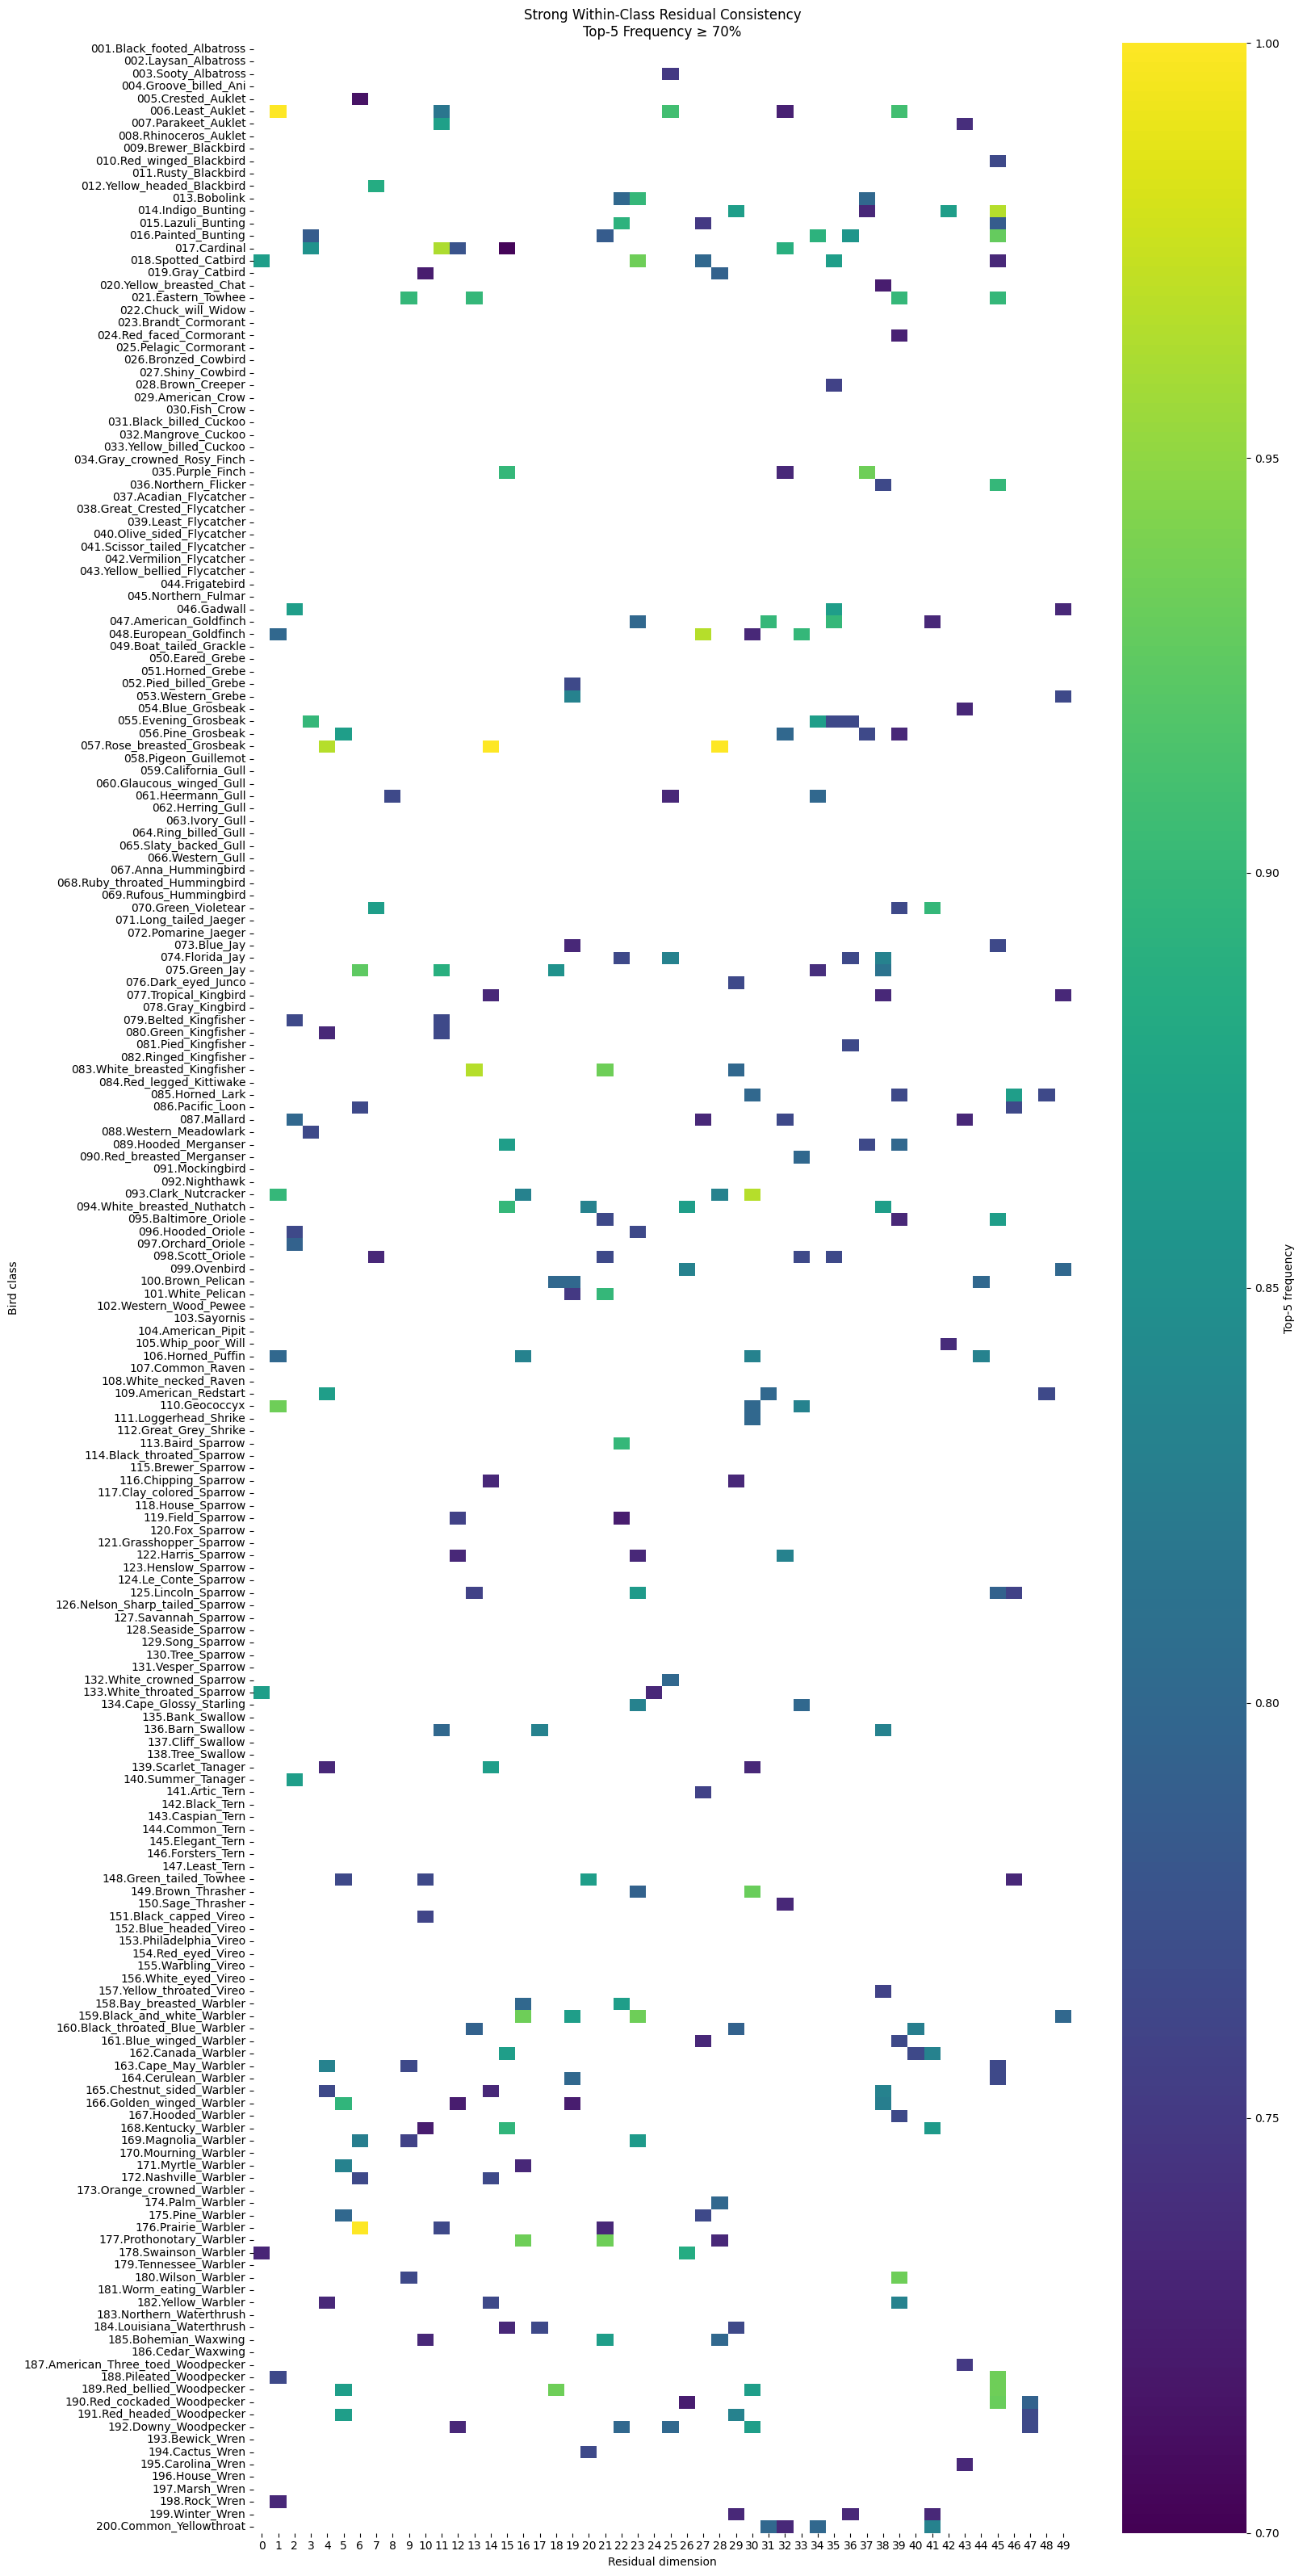

In [17]:
# ============================================================
# Heatmap: Only strong Top-5 consistency
# ============================================================

threshold = 0.7


# ------------------------------------------------------------
# Create class × residual matrix
# ------------------------------------------------------------

top5_heatmap = (
    all_residuals_per_class_df
    .pivot(
        index=["class_idx", "class_name"],
        columns="residual_idx",
        values="top5_frequency",
    )
    .sort_index(level="class_idx")
)


# Remove class_idx from displayed labels
class_labels = [
    class_name
    for _, class_name in top5_heatmap.index
]


strong_consistency = top5_heatmap.copy()

# Hide frequencies below 70%
strong_consistency = strong_consistency.where(
    strong_consistency >= threshold
)


plt.figure(figsize=(16, 32))

ax = sns.heatmap(
    strong_consistency.values,
    cmap="viridis",
    vmin=threshold,
    vmax=1,
    xticklabels=strong_consistency.columns.astype(int),
    yticklabels=class_labels,
    cbar_kws={
        "label": "Top-5 frequency"
    },
)

ax.set_xlabel("Residual dimension")
ax.set_ylabel("Bird class")

ax.set_title(
    "Strong Within-Class Residual Consistency\n"
    f"Top-5 Frequency ≥ {threshold:.0%}"
)

plt.tight_layout()
plt.show()

### Class specificity of Top-5 residual usage

In [18]:
# ============================================================
# Class specificity of Top-5 residual usage
# ============================================================

import numpy as np
import pandas as pd


df = all_residuals_per_class_df.copy()


# ------------------------------------------------------------
# Remove previously calculated columns if this cell is rerun
# ------------------------------------------------------------

columns_to_remove = [
    "top5_count",
    "total_top5_count",
    "other_class_top5_count",
    "other_class_num_samples",
    "other_class_top5_frequency",
    "top5_excess_frequency",
    "top5_lift",
    "top5_log2_lift",
]

df = df.drop(
    columns=[
        col for col in columns_to_remove
        if col in df.columns
    ]
)


# ============================================================
# 1. Number of Top-5 appearances within each class
# ============================================================

# Example:
# top5_frequency = 0.8
# num_samples = 30
#
# => residual appeared in Top-5 for 24 samples

df["top5_count"] = (
    df["top5_frequency"]
    * df["num_samples"]
)


# ============================================================
# 2. Total number of Top-5 appearances for each residual
#    across the entire test set
# ============================================================

df["total_top5_count"] = (
    df.groupby("residual_idx")["top5_count"]
    .transform("sum")
)


# Actual total number of test samples
total_num_samples = int(
    num_samples_per_class.sum().item()
)


# ============================================================
# 3. Top-5 frequency OUTSIDE the current class
# ============================================================

df["other_class_top5_count"] = (
    df["total_top5_count"]
    - df["top5_count"]
)

df["other_class_num_samples"] = (
    total_num_samples
    - df["num_samples"]
)

df["other_class_top5_frequency"] = (
    df["other_class_top5_count"]
    / df["other_class_num_samples"]
)


# ============================================================
# 4. Class specificity metrics
# ============================================================

# ------------------------------------------------------------
# Excess frequency
#
# Positive:
# residual is more frequently Top-5 for this class
#
# Zero:
# no class specificity
#
# Negative:
# residual is less frequently Top-5 for this class
# ------------------------------------------------------------

df["top5_excess_frequency"] = (
    df["top5_frequency"]
    - df["other_class_top5_frequency"]
)


# ------------------------------------------------------------
# Lift
#
# 1   = no enrichment
# 2   = twice as common for this class
# 5   = five times as common for this class
# ------------------------------------------------------------

epsilon = 1e-8

df["top5_lift"] = (
    df["top5_frequency"]
    /
    (df["other_class_top5_frequency"] + epsilon)
)


# ------------------------------------------------------------
# Log2 lift
#
# 0 = no enrichment
# 1 = 2x
# 2 = 4x
# 3 = 8x
# ------------------------------------------------------------

df["top5_log2_lift"] = np.log2(
    (df["top5_frequency"] + epsilon)
    /
    (df["other_class_top5_frequency"] + epsilon)
)


# Save back
new_all_residuals_per_class_df = df


display(
    new_all_residuals_per_class_df[
        [
            "class_idx",
            "class_name",
            "residual_idx",
            "top5_frequency",
            "other_class_top5_frequency",
            "top5_excess_frequency",
            "top5_lift",
        ]
    ].head(20)
)

new_all_residuals_per_class_df.to_csv(
    "delete_afterwards/new_all_residuals_per_class_with_lift.csv",
    index=False,
)

,class_idx,class_name,residual_idx,top5_frequency,other_class_top5_frequency,top5_excess_frequency,top5_lift
0,0,001.Black_footed_Albatross,8,0.600000,0.093511,0.506489,6.416326
1,0,001.Black_footed_Albatross,25,0.433333,0.120229,0.313104,3.604232
2,0,001.Black_footed_Albatross,32,0.500000,0.109126,0.390874,4.581876
3,0,001.Black_footed_Albatross,30,0.233333,0.132720,0.100613,1.758083
4,0,001.Black_footed_Albatross,48,0.266667,0.057078,0.209588,4.671935
5,0,001.Black_footed_Albatross,1,0.200000,0.115371,0.084629,1.733534
6,0,001.Black_footed_Albatross,7,0.366667,0.107911,0.258756,3.397856
7,0,001.Black_footed_Albatross,44,0.533333,0.067661,0.465672,7.882392
8,0,001.Black_footed_Albatross,11,0.166667,0.100278,0.066389,1.662053
9,0,001.Black_footed_Albatross,19,0.066667,0.105309,-0.038642,0.633059


#### Top 5 frequency and excess treshold

In [19]:
# ============================================================
# Strong class-residual associations
# ============================================================

TOP5_FREQ_THRESHOLD = 0.70
TOP5_EXCESS_THRESHOLD = 0.50

strong_pairs_df = new_all_residuals_per_class_df[
    (new_all_residuals_per_class_df["top5_frequency"] >= TOP5_FREQ_THRESHOLD)
    &
    (new_all_residuals_per_class_df["top5_excess_frequency"] >= TOP5_EXCESS_THRESHOLD)
].copy()

print(
    f"{len(strong_pairs_df)} strong class-residual pairs "
    f"across {strong_pairs_df['class_idx'].nunique()} classes."
)


strong_residuals_per_class_df = (
    strong_pairs_df
    .groupby(
        ["class_idx", "class_name"],
        as_index=False,
    )
    .agg(
        num_strong_residuals=("residual_idx", "nunique"),
        strong_residuals=(
            "residual_idx",
            lambda x: sorted(int(v) for v in x),
        ),
    )
    .sort_values(
        ["num_strong_residuals", "class_idx"],
        ascending=[False, True],
    )
    .reset_index(drop=True)
)

display(strong_residuals_per_class_df.head(20))


278 strong class-residual pairs across 110 classes.


,class_idx,class_name,num_strong_residuals,strong_residuals
0,5,006.Least_Auklet,5,"[1, 11, 25, 32, 39]"
1,15,016.Painted_Bunting,5,"[3, 21, 34, 36, 45]"
2,16,017.Cardinal,5,"[3, 11, 12, 15, 32]"
3,17,018.Spotted_Catbird,5,"[0, 23, 27, 35, 45]"
4,74,075.Green_Jay,5,"[6, 11, 18, 34, 38]"
5,191,192.Downy_Woodpecker,5,"[12, 22, 25, 30, 47]"
6,13,014.Indigo_Bunting,4,"[29, 37, 42, 45]"
7,20,021.Eastern_Towhee,4,"[9, 13, 39, 45]"
8,46,047.American_Goldfinch,4,"[23, 31, 35, 41]"
9,47,048.European_Goldfinch,4,"[1, 27, 30, 33]"


In [20]:
# Add class accuracy to the strong residuals table
# get accuracies from class_wise_performance_df

strong_residuals_per_class_df = strong_residuals_per_class_df.merge(
    class_wise_performance_df[
        ["class_idx", "accuracy"]
    ],
    on="class_idx",
    how="left",
)

display(strong_residuals_per_class_df.head(20))

strong_residuals_per_class_df.to_csv(
    "delete_afterwards/strong_residuals_per_class.csv",
    index=False,
)

,class_idx,class_name,num_strong_residuals,strong_residuals,accuracy
0,5,006.Least_Auklet,5,"[1, 11, 25, 32, 39]",0.909091
1,15,016.Painted_Bunting,5,"[3, 21, 34, 36, 45]",0.892857
2,16,017.Cardinal,5,"[3, 11, 12, 15, 32]",0.925926
3,17,018.Spotted_Catbird,5,"[0, 23, 27, 35, 45]",0.933333
4,74,075.Green_Jay,5,"[6, 11, 18, 34, 38]",0.962963
5,191,192.Downy_Woodpecker,5,"[12, 22, 25, 30, 47]",0.833333
6,13,014.Indigo_Bunting,4,"[29, 37, 42, 45]",0.900000
7,20,021.Eastern_Towhee,4,"[9, 13, 39, 45]",0.900000
8,46,047.American_Goldfinch,4,"[23, 31, 35, 41]",0.900000
9,47,048.European_Goldfinch,4,"[1, 27, 30, 33]",0.933333


In [21]:
# Give mean, median, min and max of accruacy for each number of strong residuals

strong_residuals_per_class_df.groupby("num_strong_residuals")["accuracy"].agg(["mean", "median", "min", "max"])
# Write mean, median, min and max of accuracy for each number of strong residuals to a new dataframe
accuracy_stats = strong_residuals_per_class_df.groupby("num_strong_residuals")["accuracy"].agg(["mean", "median", "min", "max"])
# Rename the columns to mean acc, median acc etc
accuracy_stats = accuracy_stats.rename(columns={
    "mean": "mean_acc",
    "median": "median_acc",
    "min": "min_acc",
    "max": "max_acc"
})

display(accuracy_stats)





,mean_acc,median_acc,min_acc,max_acc
num_strong_residuals,,,,
1,0.740140,0.733333,0.633333,0.884615
2,0.800012,0.800000,0.655172,0.931034
3,0.858279,0.862069,0.700000,1.000000
4,0.871204,0.900000,0.733333,0.933333
5,0.909584,0.917508,0.833333,0.962963


In [22]:
# ============================================================
# Distribution:
# number of classes by number of strong residuals
# ============================================================

# Get all classes from the original dataframe
all_classes_df = (
    new_all_residuals_per_class_df[
        ["class_idx", "class_name"]
    ]
    .drop_duplicates()
)


# ------------------------------------------------------------
# Add classes with zero strong residuals
# ------------------------------------------------------------

class_strong_counts_df = (
    all_classes_df
    .merge(
        strong_residuals_per_class_df[
            [
                "class_idx",
                "num_strong_residuals",
            ]
        ],
        on="class_idx",
        how="left",
    )
)

class_strong_counts_df["num_strong_residuals"] = (
    class_strong_counts_df["num_strong_residuals"]
    .fillna(0)
    .astype(int)
)


# ------------------------------------------------------------
# Distribution
# ------------------------------------------------------------

strong_residual_distribution_df = (
    class_strong_counts_df[
        "num_strong_residuals"
    ]
    .value_counts()
    .sort_index()
    .rename_axis("num_strong_residuals")
    .reset_index(name="num_classes")
)


display(strong_residual_distribution_df)

,num_strong_residuals,num_classes
0,0,90
1,1,29
2,2,25
3,3,31
4,4,19
5,5,6


In [23]:
strong_classes_per_residual_df = (
    strong_pairs_df
    .groupby(
        "residual_idx",
        as_index=False,
    )
    .agg(
        num_strongly_associated_classes=(
            "class_idx",
            "nunique",
        ),
        associated_classes=(
            "class_name",
            lambda x: sorted(x.tolist()),
        ),
    )
    .sort_values(
        ["num_strongly_associated_classes", "residual_idx"],
        ascending=[False, True],
    )
    .reset_index(drop=True)
)

display(
    strong_classes_per_residual_df[
        [
            "residual_idx",
            "num_strongly_associated_classes",
        ]
    ].head(20)
)

,residual_idx,num_strongly_associated_classes
0,45,15
1,39,12
2,23,10
3,30,10
4,38,10
5,11,8
6,19,8
7,21,8
8,29,8
9,32,8


#### Heatmap of strong class-residual associations (frequency + excess thresholds)

278 strong class-residual pairs across 200 classes (top5_frequency ≥ 70%, top5_excess_frequency ≥ 50%).


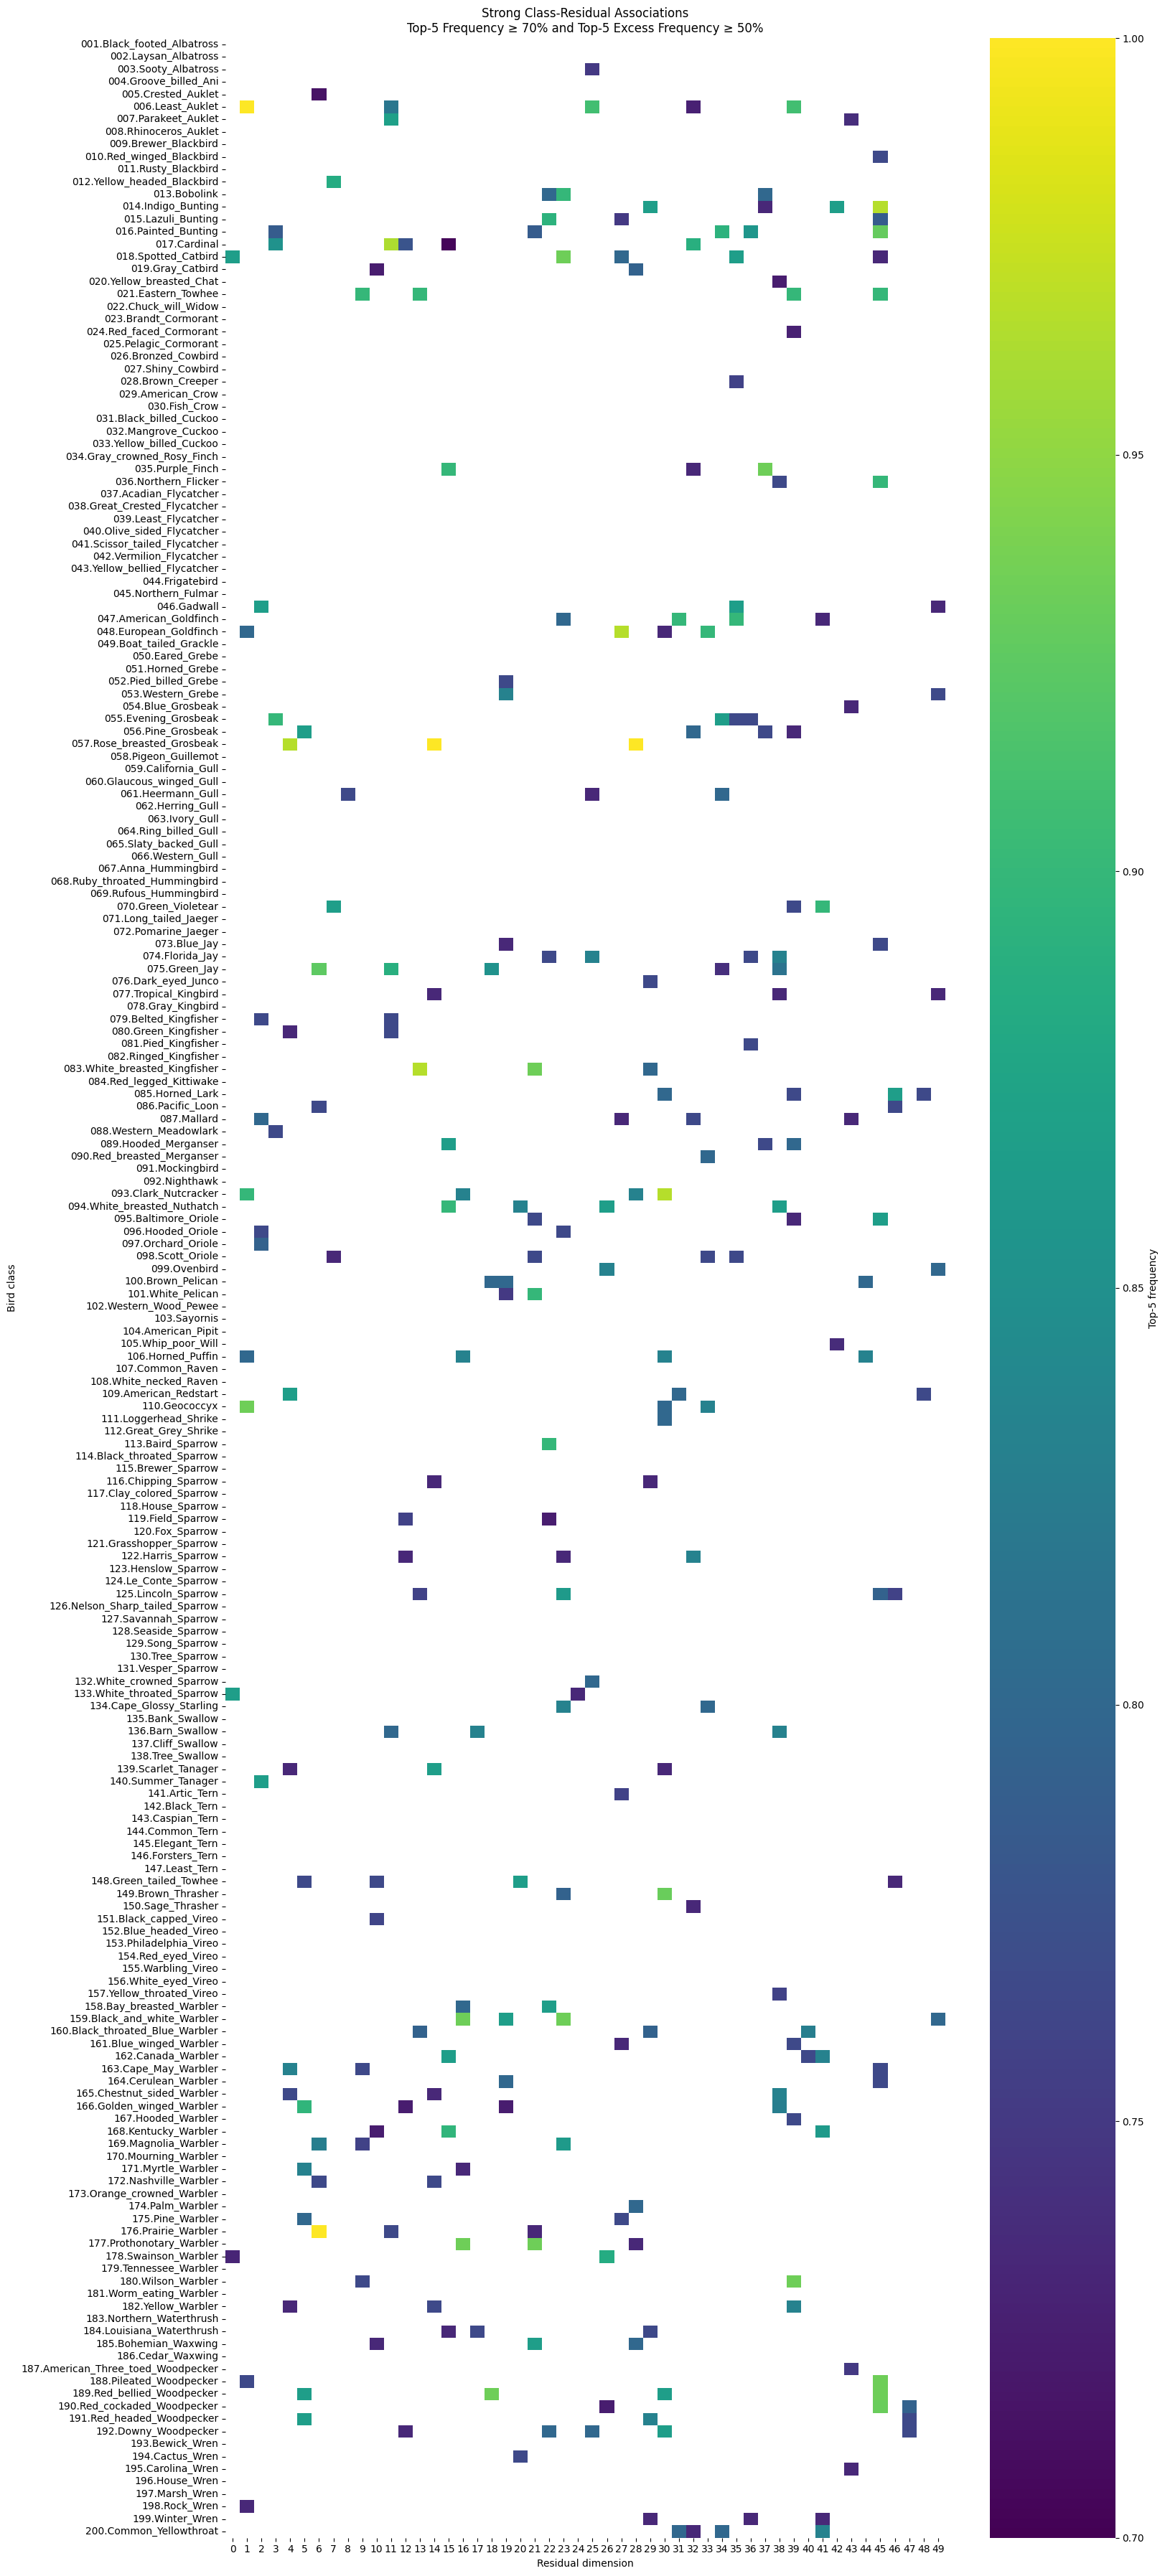

In [24]:
# ============================================================
# Heatmap: Only strong class-residual associations
# (Top-5 frequency AND Top-5 excess frequency above threshold)
# ============================================================

# Reuse the thresholds from the strong-pairs cell above
FREQ_THRESHOLD = TOP5_FREQ_THRESHOLD
EXCESS_THRESHOLD = TOP5_EXCESS_THRESHOLD

# Show only classes that have at least one strong residual
ONLY_STRONG_CLASSES = False


# ------------------------------------------------------------
# Create class × residual matrices
# ------------------------------------------------------------

freq_matrix = (
    new_all_residuals_per_class_df
    .pivot(
        index=["class_idx", "class_name"],
        columns="residual_idx",
        values="top5_frequency",
    )
    .sort_index(level="class_idx")
)

excess_matrix = (
    new_all_residuals_per_class_df
    .pivot(
        index=["class_idx", "class_name"],
        columns="residual_idx",
        values="top5_excess_frequency",
    )
    .sort_index(level="class_idx")
    .reindex(
        index=freq_matrix.index,
        columns=freq_matrix.columns,
    )
)


# ------------------------------------------------------------
# Keep only cells where BOTH thresholds are surpassed
# ------------------------------------------------------------

strong_mask = (
    (freq_matrix >= FREQ_THRESHOLD)
    &
    (excess_matrix >= EXCESS_THRESHOLD)
)

strong_association = freq_matrix.where(strong_mask)


if ONLY_STRONG_CLASSES:
    rows_with_strong = strong_mask.any(axis=1)

    strong_association = strong_association[rows_with_strong]
    strong_mask = strong_mask[rows_with_strong]


# Remove class_idx from displayed labels
class_labels = [
    class_name
    for _, class_name in strong_association.index
]


print(
    f"{int(strong_mask.values.sum())} strong class-residual pairs "
    f"across {len(strong_association)} classes "
    f"(top5_frequency ≥ {FREQ_THRESHOLD:.0%}, "
    f"top5_excess_frequency ≥ {EXCESS_THRESHOLD:.0%})."
)


# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------

fig_height = max(4, 0.18 * len(strong_association))

plt.figure(figsize=(16, fig_height))

ax = sns.heatmap(
    strong_association.values,
    cmap="viridis",
    vmin=FREQ_THRESHOLD,
    vmax=1,
    xticklabels=strong_association.columns.astype(int),
    yticklabels=class_labels,
    cbar_kws={
        "label": "Top-5 frequency"
    },
)

ax.set_xlabel("Residual dimension")
ax.set_ylabel("Bird class")

ax.set_title(
    "Strong Class-Residual Associations\n"
    f"Top-5 Frequency ≥ {FREQ_THRESHOLD:.0%} "
    f"and Top-5 Excess Frequency ≥ {EXCESS_THRESHOLD:.0%}"
)

plt.tight_layout()
plt.show()


## Random shuffle of residual activations

In [25]:
# ============================================================
# Residual-shuffle null experiment
# ============================================================
#
# Purpose:
# Test whether the observed class-specific residual associations
# are caused by the residual ACTIVATIONS, rather than mainly by
# the classifier-head contrasts u_r.
#
# We KEEP FIXED:
#   - u_r
#   - y_true
#   - predictions / top1_class
#   - W_r
#
# We SHUFFLE:
#   - rows of centered_r
#
# Therefore an image keeps its original classifier contrast u_r,
# but receives the residual representation from another image.
# ============================================================

import torch
import numpy as np
import pandas as pd


TOP_K = 5

# Same thresholds as your original analysis
TOP5_FREQ_THRESHOLD = 0.70
TOP5_EXCESS_THRESHOLD = 0.50


def compute_top5_class_specificity(
    signed_phi,
    y_true,
    num_classes,
    R,
    top_k=5,
):
    """
    Compute exactly the quantities used in the notebook's
    class-specific Top-5 residual analysis.

    Parameters
    ----------
    signed_phi : Tensor [N, R]
        Signed residual attribution values (phi_r). The Top-k
        are the k most positive contributions per sample.

    y_true : Tensor [N]
        True class labels.

    num_classes : int
        Number of classes.

    R : int
        Number of residual dimensions.

    top_k : int
        Number of residuals considered important per sample.

    Returns
    -------
    dict containing:
        top5_frequency
        other_class_top5_frequency
        top5_excess_frequency
        strong_mask
        top5_counts
    """

    device = signed_phi.device

    y = y_true.to(device).long().view(-1)

    N = signed_phi.shape[0]

    assert signed_phi.shape == (N, R)
    assert y.shape[0] == N


    # --------------------------------------------------------
    # 1. Top-k residuals for every sample
    # --------------------------------------------------------

    topk_idx = torch.topk(
        signed_phi,
        k=top_k,
        dim=1,
        largest=True,
    ).indices
    # [N, top_k]


    # Binary matrix:
    #
    # topk_mask[n, j] = 1
    #
    # if residual j is in sample n's Top-k.
    topk_mask = torch.zeros(
        (N, R),
        dtype=torch.float32,
        device=device,
    )

    topk_mask.scatter_(
        1,
        topk_idx,
        1.0,
    )


    # --------------------------------------------------------
    # 2. Number of samples per class
    # --------------------------------------------------------

    class_counts = torch.bincount(
        y,
        minlength=num_classes,
    ).float()

    # [K, 1]
    class_counts_col = class_counts.unsqueeze(1)


    # --------------------------------------------------------
    # 3. Top-5 counts within each class
    # --------------------------------------------------------

    # Shape: [K, R]
    class_top5_counts = torch.zeros(
        (num_classes, R),
        dtype=torch.float32,
        device=device,
    )

    # For each sample n:
    #
    # add topk_mask[n] to row y_true[n]
    class_top5_counts.index_add_(
        0,
        y,
        topk_mask,
    )


    # --------------------------------------------------------
    # 4. Within-class frequency
    # --------------------------------------------------------
    # count of samples in each class is class_counts_col
    
    top5_frequency = (
        class_top5_counts
        / class_counts_col.clamp_min(1)
    )


    # --------------------------------------------------------
    # 5. Frequency outside each class
    # --------------------------------------------------------

    # Total Top-k appearances of each residual
    total_top5_counts = topk_mask.sum(dim=0)
    # [R]


    other_class_top5_counts = (
        total_top5_counts.unsqueeze(0)
        - class_top5_counts
    )


    other_class_counts = (
        N
        - class_counts_col
    )


    other_class_top5_frequency = (
        other_class_top5_counts
        / other_class_counts.clamp_min(1)
    )


    # --------------------------------------------------------
    # 6. Excess frequency
    # --------------------------------------------------------

    top5_excess_frequency = (
        top5_frequency
        - other_class_top5_frequency
    )


    # --------------------------------------------------------
    # 7. Apply your "strong association" thresholds
    # --------------------------------------------------------

    strong_mask = (
        (top5_frequency >= TOP5_FREQ_THRESHOLD)
        &
        (
            top5_excess_frequency
            >= TOP5_EXCESS_THRESHOLD
        )
    )


    return {
        "top5_frequency":
            top5_frequency,

        "other_class_top5_frequency":
            other_class_top5_frequency,

        "top5_excess_frequency":
            top5_excess_frequency,

        "strong_mask":
            strong_mask,

        "class_top5_counts":
            class_top5_counts,

        "class_counts":
            class_counts,
    }

In [26]:
# ============================================================
# Sanity check: reproduce the original result
# ============================================================

observed_metrics = compute_top5_class_specificity(
    signed_phi=signed_phi_r,
    y_true=y_true,
    num_classes=num_classes,
    R=R,
    top_k=TOP_K,
)


observed_strong_mask = (
    observed_metrics["strong_mask"]
)


observed_num_strong_pairs = int(
    observed_strong_mask.sum().item()
)


observed_num_classes_with_strong = int(
    observed_strong_mask
    .any(dim=1)
    .sum()
    .item()
)


print(
    f"Observed strong pairs: "
    f"{observed_num_strong_pairs}"
)

print(
    f"Classes with >=1 strong residual: "
    f"{observed_num_classes_with_strong}"
)

Observed strong pairs: 313
Classes with >=1 strong residual: 114


In [27]:
# ============================================================
# Diagnose 279 vs 320 discrepancy
# ============================================================

diagnostic_df = new_all_residuals_per_class_df.copy()

# Values calculated by the new helper function
diagnostic_df["helper_top5_frequency"] = [
    observed_metrics["top5_frequency"][
        int(row.class_idx),
        int(row.residual_idx)
    ].item()
    for row in diagnostic_df.itertuples()
]

diagnostic_df["helper_excess_frequency"] = [
    observed_metrics["top5_excess_frequency"][
        int(row.class_idx),
        int(row.residual_idx)
    ].item()
    for row in diagnostic_df.itertuples()
]


# ------------------------------------------------------------
# Original notebook criterion
# ------------------------------------------------------------

diagnostic_df["original_strong"] = (
    (diagnostic_df["top5_frequency"] >= 0.70)
    &
    (diagnostic_df["top5_excess_frequency"] >= 0.50)
)


# ------------------------------------------------------------
# New helper criterion
# ------------------------------------------------------------

diagnostic_df["helper_strong"] = (
    (diagnostic_df["helper_top5_frequency"] >= 0.70)
    &
    (diagnostic_df["helper_excess_frequency"] >= 0.50)
)


# ------------------------------------------------------------
# Find disagreements
# ------------------------------------------------------------

mismatch_df = diagnostic_df[
    diagnostic_df["original_strong"]
    != diagnostic_df["helper_strong"]
].copy()


print("Original strong pairs:", diagnostic_df["original_strong"].sum())
print("Helper strong pairs:", diagnostic_df["helper_strong"].sum())
print("Number of mismatches:", len(mismatch_df))


display(
    mismatch_df[
        [
            "class_idx",
            "class_name",
            "residual_idx",
            "top5_frequency",
            "helper_top5_frequency",
            "top5_excess_frequency",
            "helper_excess_frequency",
            "original_strong",
            "helper_strong",
        ]
    ]
)

Original strong pairs: 278
Helper strong pairs: 278
Number of mismatches: 0


,class_idx,class_name,residual_idx,top5_frequency,helper_top5_frequency,top5_excess_frequency,helper_excess_frequency,original_strong,helper_strong


In [28]:
# ============================================================
# Correct diagnostic: compare original mask vs PyTorch mask
# ============================================================

diagnostic_df = new_all_residuals_per_class_df.copy()


# Original notebook definition
diagnostic_df["original_strong"] = (
    (diagnostic_df["top5_frequency"] >= 0.70)
    &
    (diagnostic_df["top5_excess_frequency"] >= 0.50)
)


# ACTUAL strong mask produced inside helper
diagnostic_df["torch_strong"] = [
    bool(
        observed_metrics["strong_mask"][
            int(row.class_idx),
            int(row.residual_idx)
        ].item()
    )
    for row in diagnostic_df.itertuples()
]


# Also store raw PyTorch values
diagnostic_df["torch_top5_frequency"] = [
    observed_metrics["top5_frequency"][
        int(row.class_idx),
        int(row.residual_idx)
    ].item()
    for row in diagnostic_df.itertuples()
]

diagnostic_df["torch_excess_frequency"] = [
    observed_metrics["top5_excess_frequency"][
        int(row.class_idx),
        int(row.residual_idx)
    ].item()
    for row in diagnostic_df.itertuples()
]


# Find disagreement
mismatch_df = diagnostic_df[
    diagnostic_df["original_strong"]
    != diagnostic_df["torch_strong"]
].copy()


print("Original:", diagnostic_df["original_strong"].sum())
print("PyTorch:", diagnostic_df["torch_strong"].sum())
print("Mismatches:", len(mismatch_df))

Original: 278
PyTorch: 313
Mismatches: 35


In [29]:
pd.set_option("display.precision", 12)

display(
    mismatch_df[
        [
            "class_idx",
            "class_name",
            "residual_idx",
            "top5_frequency",
            "torch_top5_frequency",
            "top5_excess_frequency",
            "torch_excess_frequency",
            "original_strong",
            "torch_strong",
        ]
    ]
)

,class_idx,class_name,residual_idx,top5_frequency,torch_top5_frequency,top5_excess_frequency,torch_excess_frequency,original_strong,torch_strong
1704,34,035.Purple_Finch,7,0.699999988079,0.699999988079,0.593823719765,0.593823730946,False,True
1851,37,038.Great_Crested_Flycatcher,31,0.699999988079,0.699999988079,0.607702970267,0.607702970505,False,True
2550,51,052.Pied_billed_Grebe,44,0.699999988079,0.699999988079,0.633206093858,0.633206069469,False,True
2806,56,057.Rose_breasted_Grosbeak,37,0.699999988079,0.699999988079,0.616377502165,0.616377472878,False,True
3458,69,070.Green_Violetear,16,0.699999988079,0.699999988079,0.584455225442,0.584455251694,False,True
3603,72,073.Blue_Jay,33,0.699999988079,0.699999988079,0.618632880714,0.618632912636,False,True
3750,75,076.Dark_eyed_Junco,17,0.699999988079,0.699999988079,0.623317127925,0.623317122459,False,True
3808,76,077.Tropical_Kingbird,6,0.699999988079,0.699999988079,0.624184580928,0.624184608459,False,True
3952,79,080.Green_Kingfisher,29,0.699999988079,0.699999988079,0.595385135712,0.595385134220,False,True
4304,86,087.Mallard,29,0.699999988079,0.699999988079,0.595385135712,0.595385134220,False,True


### Perform shuffling

In [30]:
# ============================================================
# Single residual-row shuffle
# ============================================================

SEED = 42

torch.manual_seed(SEED)


# Randomly assign each test sample the residual representation
# from another test sample.
perm = torch.randperm(
    num_samples,
    device=centered_r.device,
)

# centered_r = test_r_prob_mean - r_train_base_rate
centered_r_shuffled = centered_r[perm]


# IMPORTANT:
#
# u_r is NOT shuffled.
#
# Original:
# phi_r[n,j] = u_r[n,j] * centered_r[n,j]
#
# Null:
# phi_r[n,j] = u_r[n,j] * centered_r[random_sample,j]
#
phi_r_shuffled = (
    u_r
    * centered_r_shuffled
)

signed_phi_r_shuffled = phi_r_shuffled


shuffled_metrics = compute_top5_class_specificity(
    signed_phi=signed_phi_r_shuffled,
    y_true=y_true,
    num_classes=num_classes,
    R=R,
    top_k=TOP_K,
)


shuffled_num_strong_pairs = int(
    shuffled_metrics["strong_mask"]
    .sum()
    .item()
)


shuffled_num_classes_with_strong = int(
    shuffled_metrics["strong_mask"]
    .any(dim=1)
    .sum()
    .item()
)


print(
    f"Observed strong pairs: "
    f"{observed_num_strong_pairs}"
)

print(
    f"Shuffled strong pairs: "
    f"{shuffled_num_strong_pairs}"
)

print()

print(
    f"Observed classes with >=1 strong residual: "
    f"{observed_num_classes_with_strong}"
)

print(
    f"Shuffled classes with >=1 strong residual: "
    f"{shuffled_num_classes_with_strong}"
)

Observed strong pairs: 313
Shuffled strong pairs: 1

Observed classes with >=1 strong residual: 114
Shuffled classes with >=1 strong residual: 1


## AUC

In [31]:
# ============================================================
# Class-specific residual AUC
# ============================================================
#
# For each class c and residual j:
#
#   AUC[c, j] = P(
#       residual j activation for class c
#       >
#       residual j activation outside class c
#   )
#
# Interpretation:
#
#   AUC = 0.50 -> no class specificity
#   AUC > 0.50 -> residual is higher for this class
#   AUC < 0.50 -> residual is lower for this class
#
# Strength of association:
#
#   abs(AUC - 0.50)
#
# ============================================================

import numpy as np
import pandas as pd
import torch

from sklearn.metrics import roc_auc_score


# ------------------------------------------------------------
# Prepare arrays
# ------------------------------------------------------------

# centered_r: [N, R]
#
# Using centered_r is fine because subtracting a constant
# per residual does not change AUC.
residual_scores = (
    centered_r
    .detach()
    .cpu()
    .numpy()
)

labels = (
    y_true
    .detach()
    .cpu()
    .numpy()
    .astype(int)
)


N, R_check = residual_scores.shape

assert R_check == R
assert len(labels) == N


# ------------------------------------------------------------
# Compute class-vs-rest AUC
# ------------------------------------------------------------

auc_matrix = np.full(
    (num_classes, R),
    np.nan,
    dtype=float,
)


for class_idx in range(num_classes):

    # Binary target:
    #
    # 1 = sample belongs to this class
    # 0 = sample belongs to another class
    binary_target = (
        labels == class_idx
    ).astype(int)

    for residual_idx in range(R):

        scores = residual_scores[
            :,
            residual_idx
        ]

        auc_matrix[
            class_idx,
            residual_idx
        ] = roc_auc_score(
            binary_target,
            scores,
        )


print("AUC matrix shape:", auc_matrix.shape)

print(
    "Mean |AUC - 0.5|:",
    np.mean(np.abs(auc_matrix - 0.5))
)

print(
    "Maximum AUC:",
    np.nanmax(auc_matrix)
)

print(
    "Minimum AUC:",
    np.nanmin(auc_matrix)
)

AUC matrix shape: (200, 50)
Mean |AUC - 0.5|: 0.21700344817935935
Maximum AUC: 0.9717701827434652
Minimum AUC: 0.03293141337034465


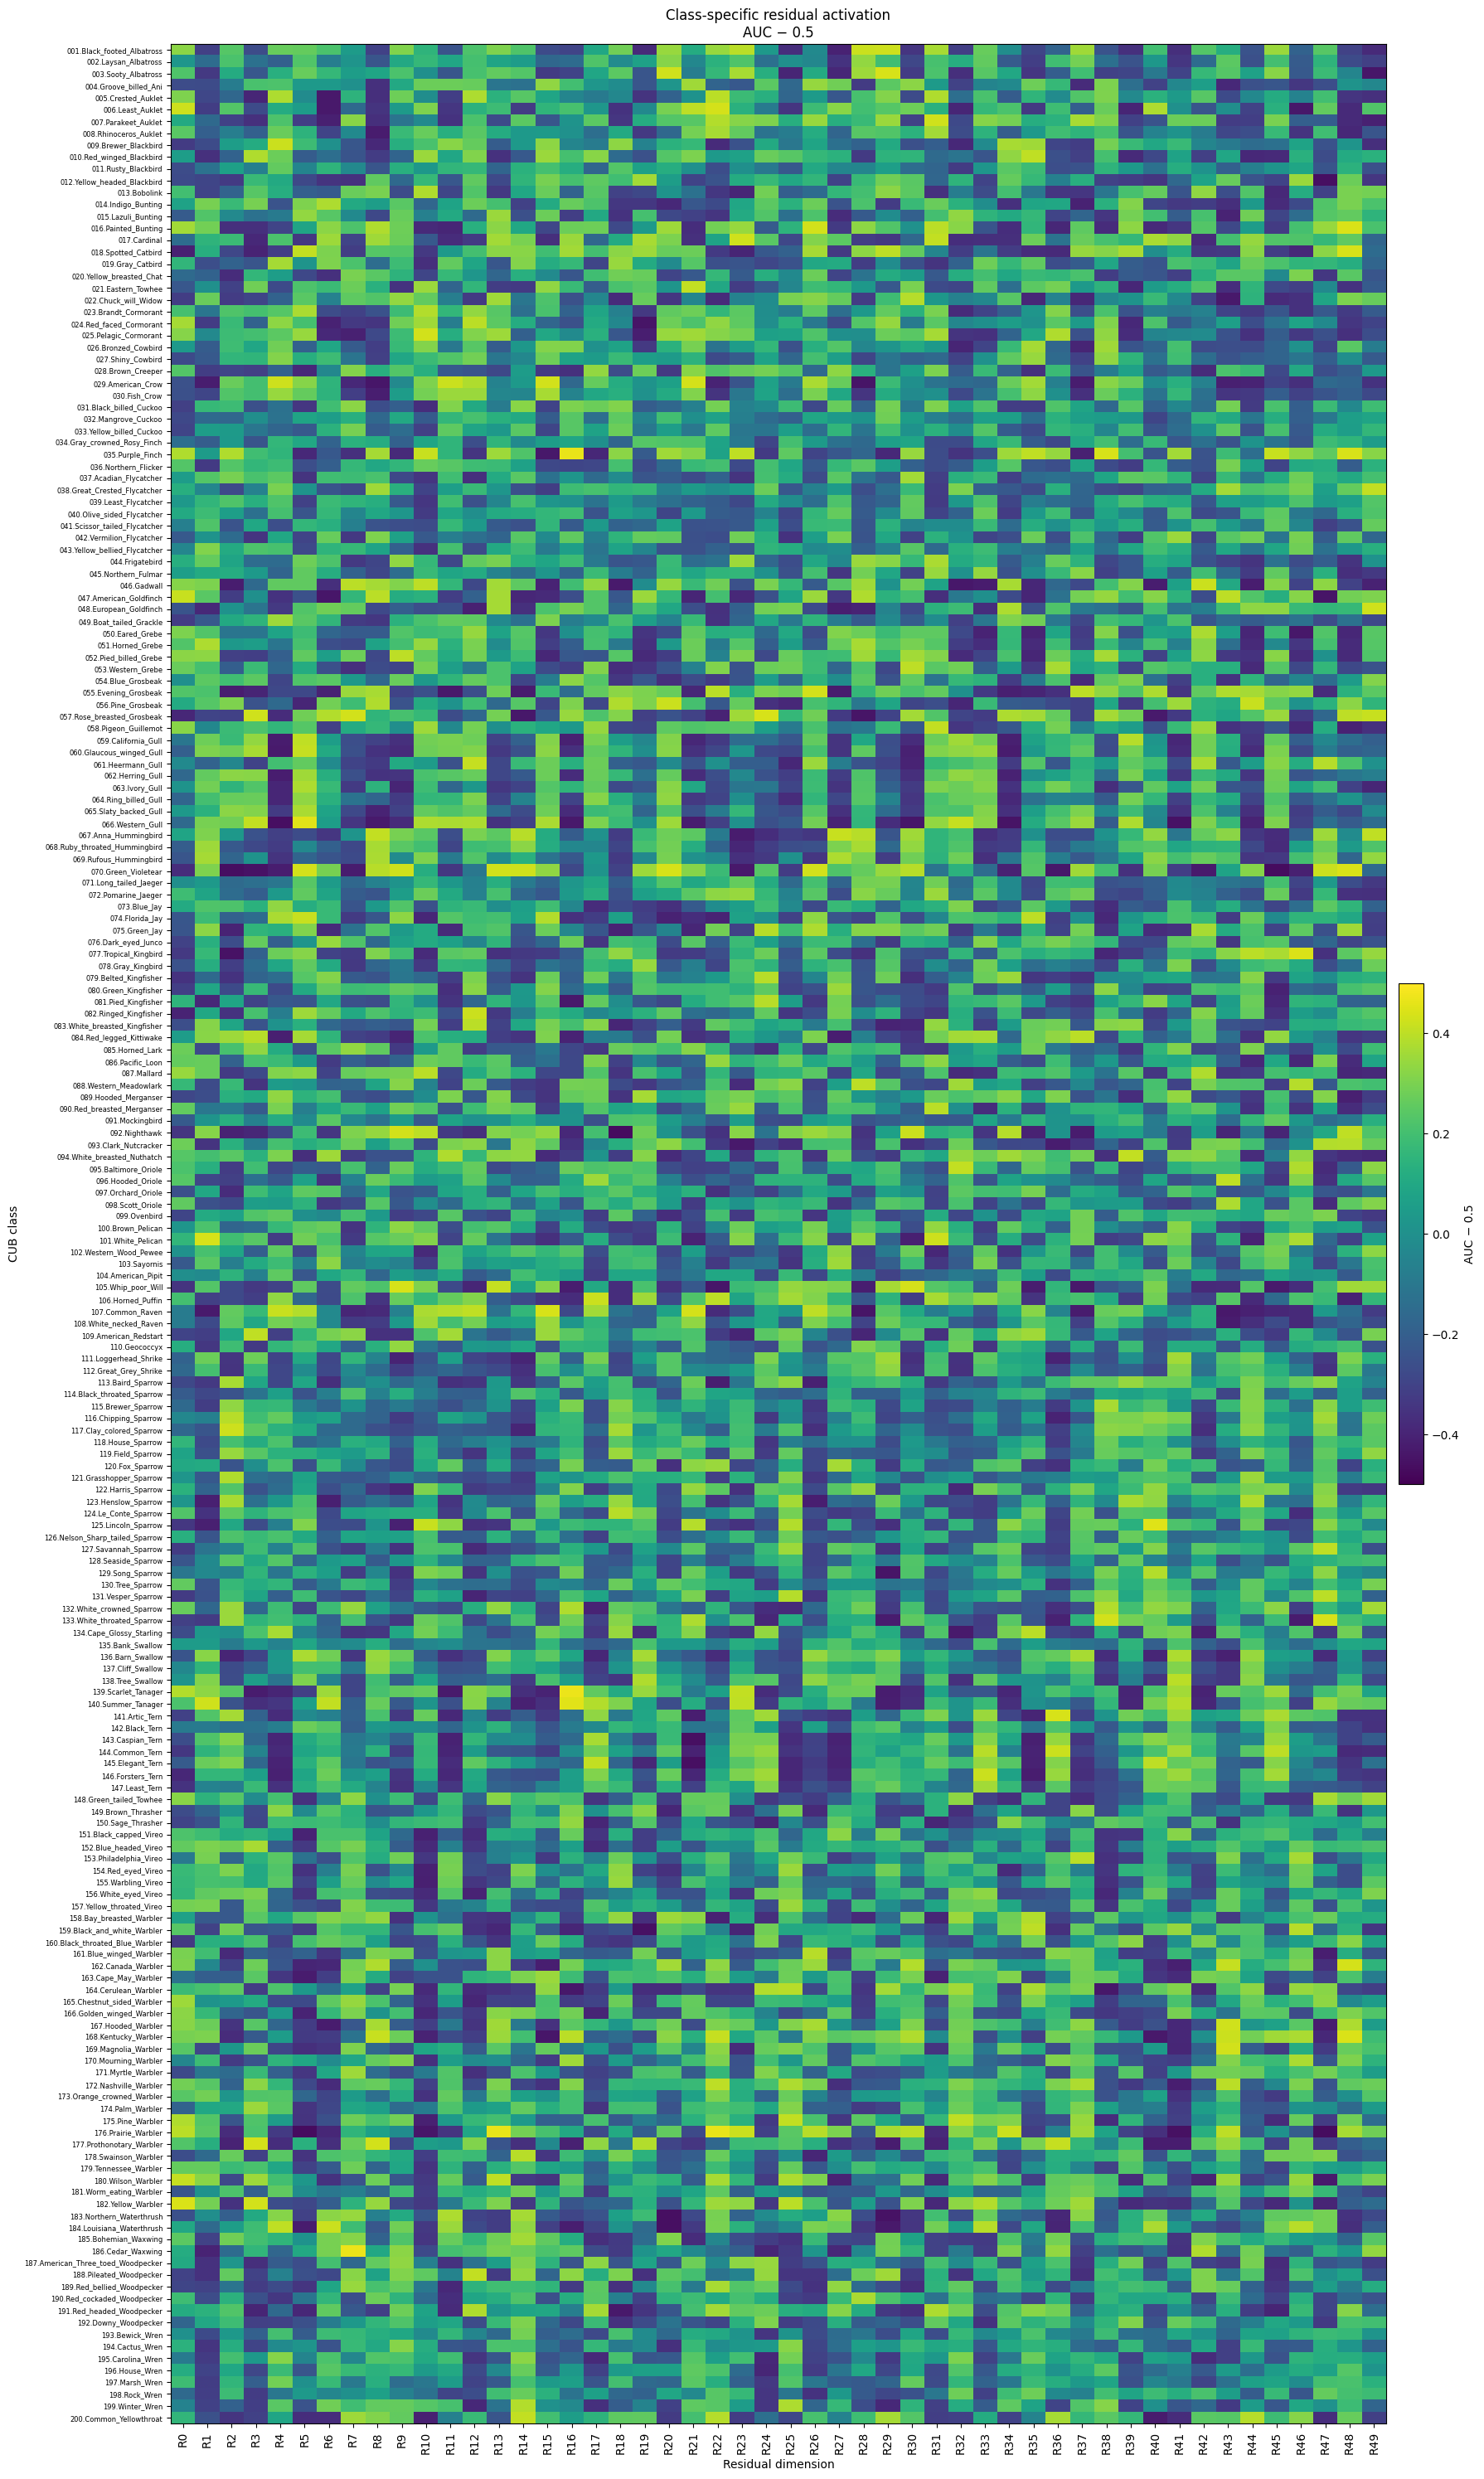

In [32]:
# ============================================================
# Heatmap: class-residual AUC
# ============================================================

import matplotlib.pyplot as plt


auc_direction_matrix = (
    auc_matrix - 0.5
)


fig, ax = plt.subplots(
    figsize=(18, 30)
)


im = ax.imshow(
    auc_direction_matrix,
    aspect="auto",
    interpolation="nearest",
    vmin=-0.5,
    vmax=0.5,
)


# ------------------------------------------------------------
# X-axis: residuals
# ------------------------------------------------------------

ax.set_xticks(
    np.arange(R)
)

ax.set_xticklabels(
    [
        f"R{j}"
        for j in range(R)
    ],
    rotation=90,
)


# ------------------------------------------------------------
# Y-axis: classes
# ------------------------------------------------------------

ax.set_yticks(
    np.arange(num_classes)
)

ax.set_yticklabels(
    class_names_names,
    fontsize=6,
)


ax.set_xlabel(
    "Residual dimension"
)

ax.set_ylabel(
    "CUB class"
)

ax.set_title(
    "Class-specific residual activation\n"
    "AUC − 0.5"
)


# ------------------------------------------------------------
# Colour bar
# ------------------------------------------------------------

cbar = fig.colorbar(
    im,
    ax=ax,
    fraction=0.02,
    pad=0.01,
)

cbar.set_label(
    "AUC − 0.5"
)


plt.tight_layout()
plt.show()

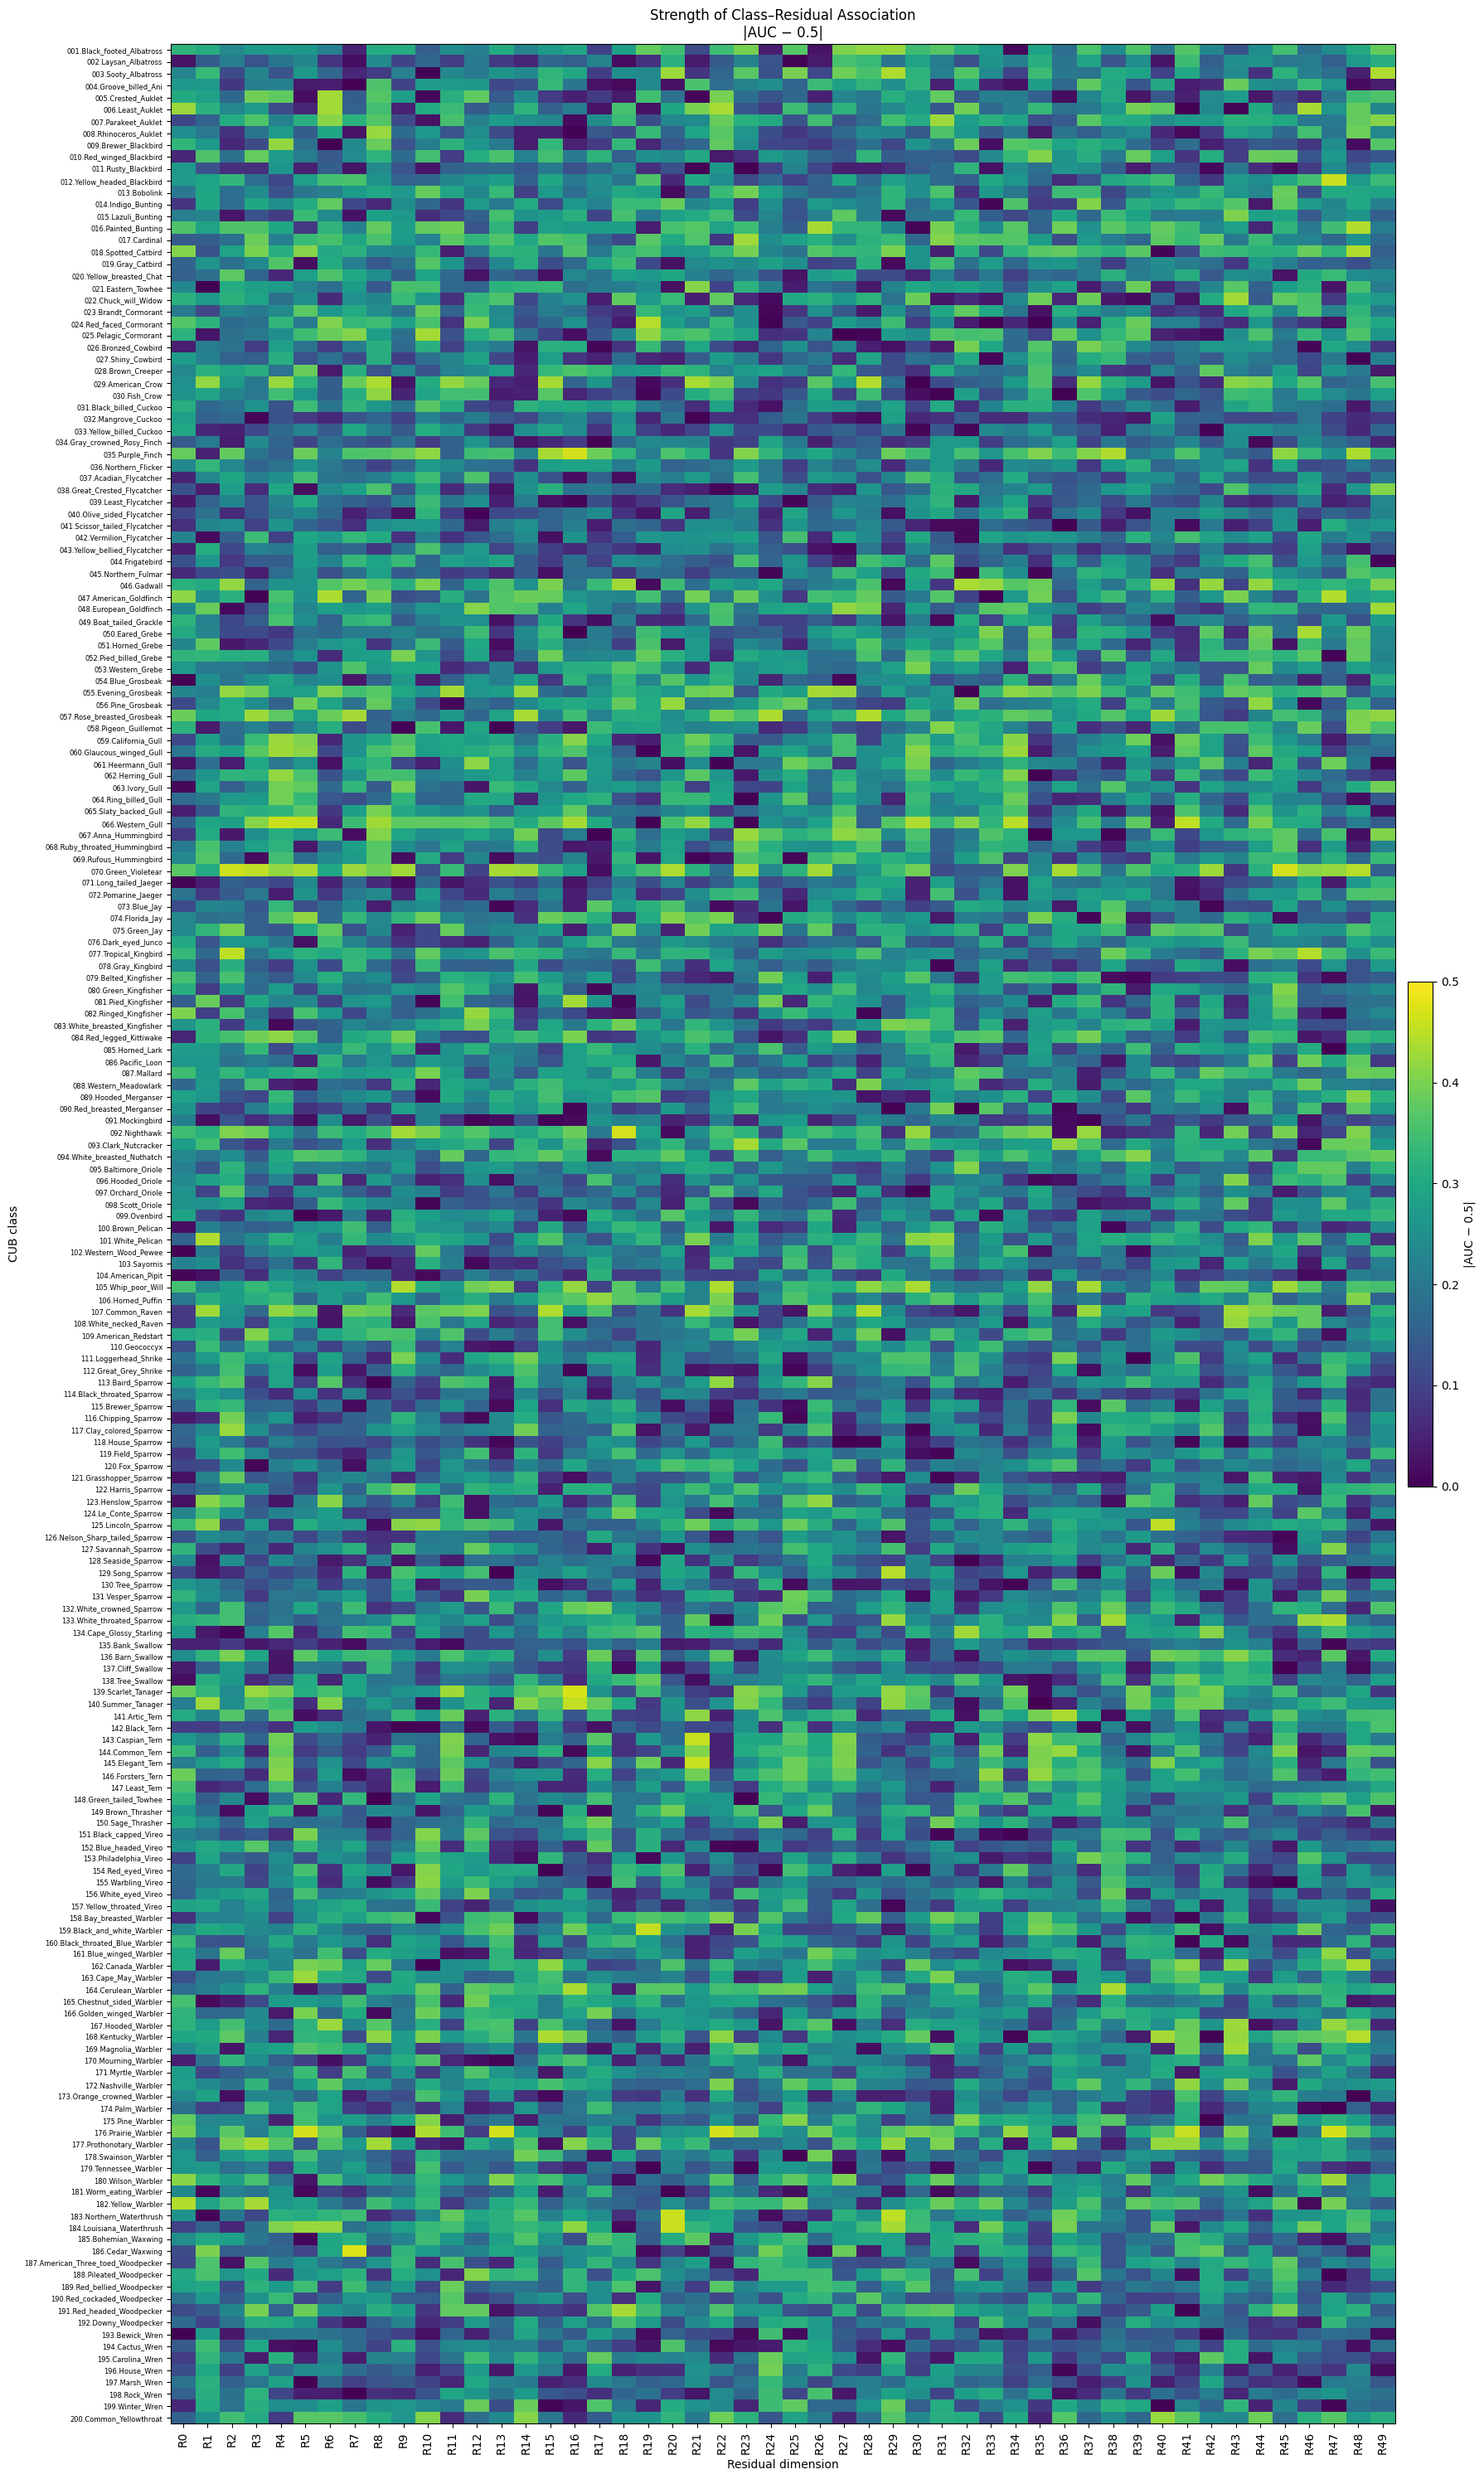

In [33]:
# ============================================================
# Heatmap: strength of class-residual association
# ============================================================

auc_strength_matrix = np.abs(
    auc_matrix - 0.5
)


fig, ax = plt.subplots(
    figsize=(18, 30)
)


im = ax.imshow(
    auc_strength_matrix,
    aspect="auto",
    interpolation="nearest",
    vmin=0.0,
    vmax=0.5,
)


ax.set_xticks(
    np.arange(R)
)

ax.set_xticklabels(
    [
        f"R{j}"
        for j in range(R)
    ],
    rotation=90,
)


ax.set_yticks(
    np.arange(num_classes)
)

ax.set_yticklabels(
    class_names_names,
    fontsize=6,
)


ax.set_xlabel(
    "Residual dimension"
)

ax.set_ylabel(
    "CUB class"
)

ax.set_title(
    "Strength of Class–Residual Association\n"
    "|AUC − 0.5|"
)


cbar = fig.colorbar(
    im,
    ax=ax,
    fraction=0.02,
    pad=0.01,
)

cbar.set_label(
    "|AUC − 0.5|"
)


plt.tight_layout()
plt.show()

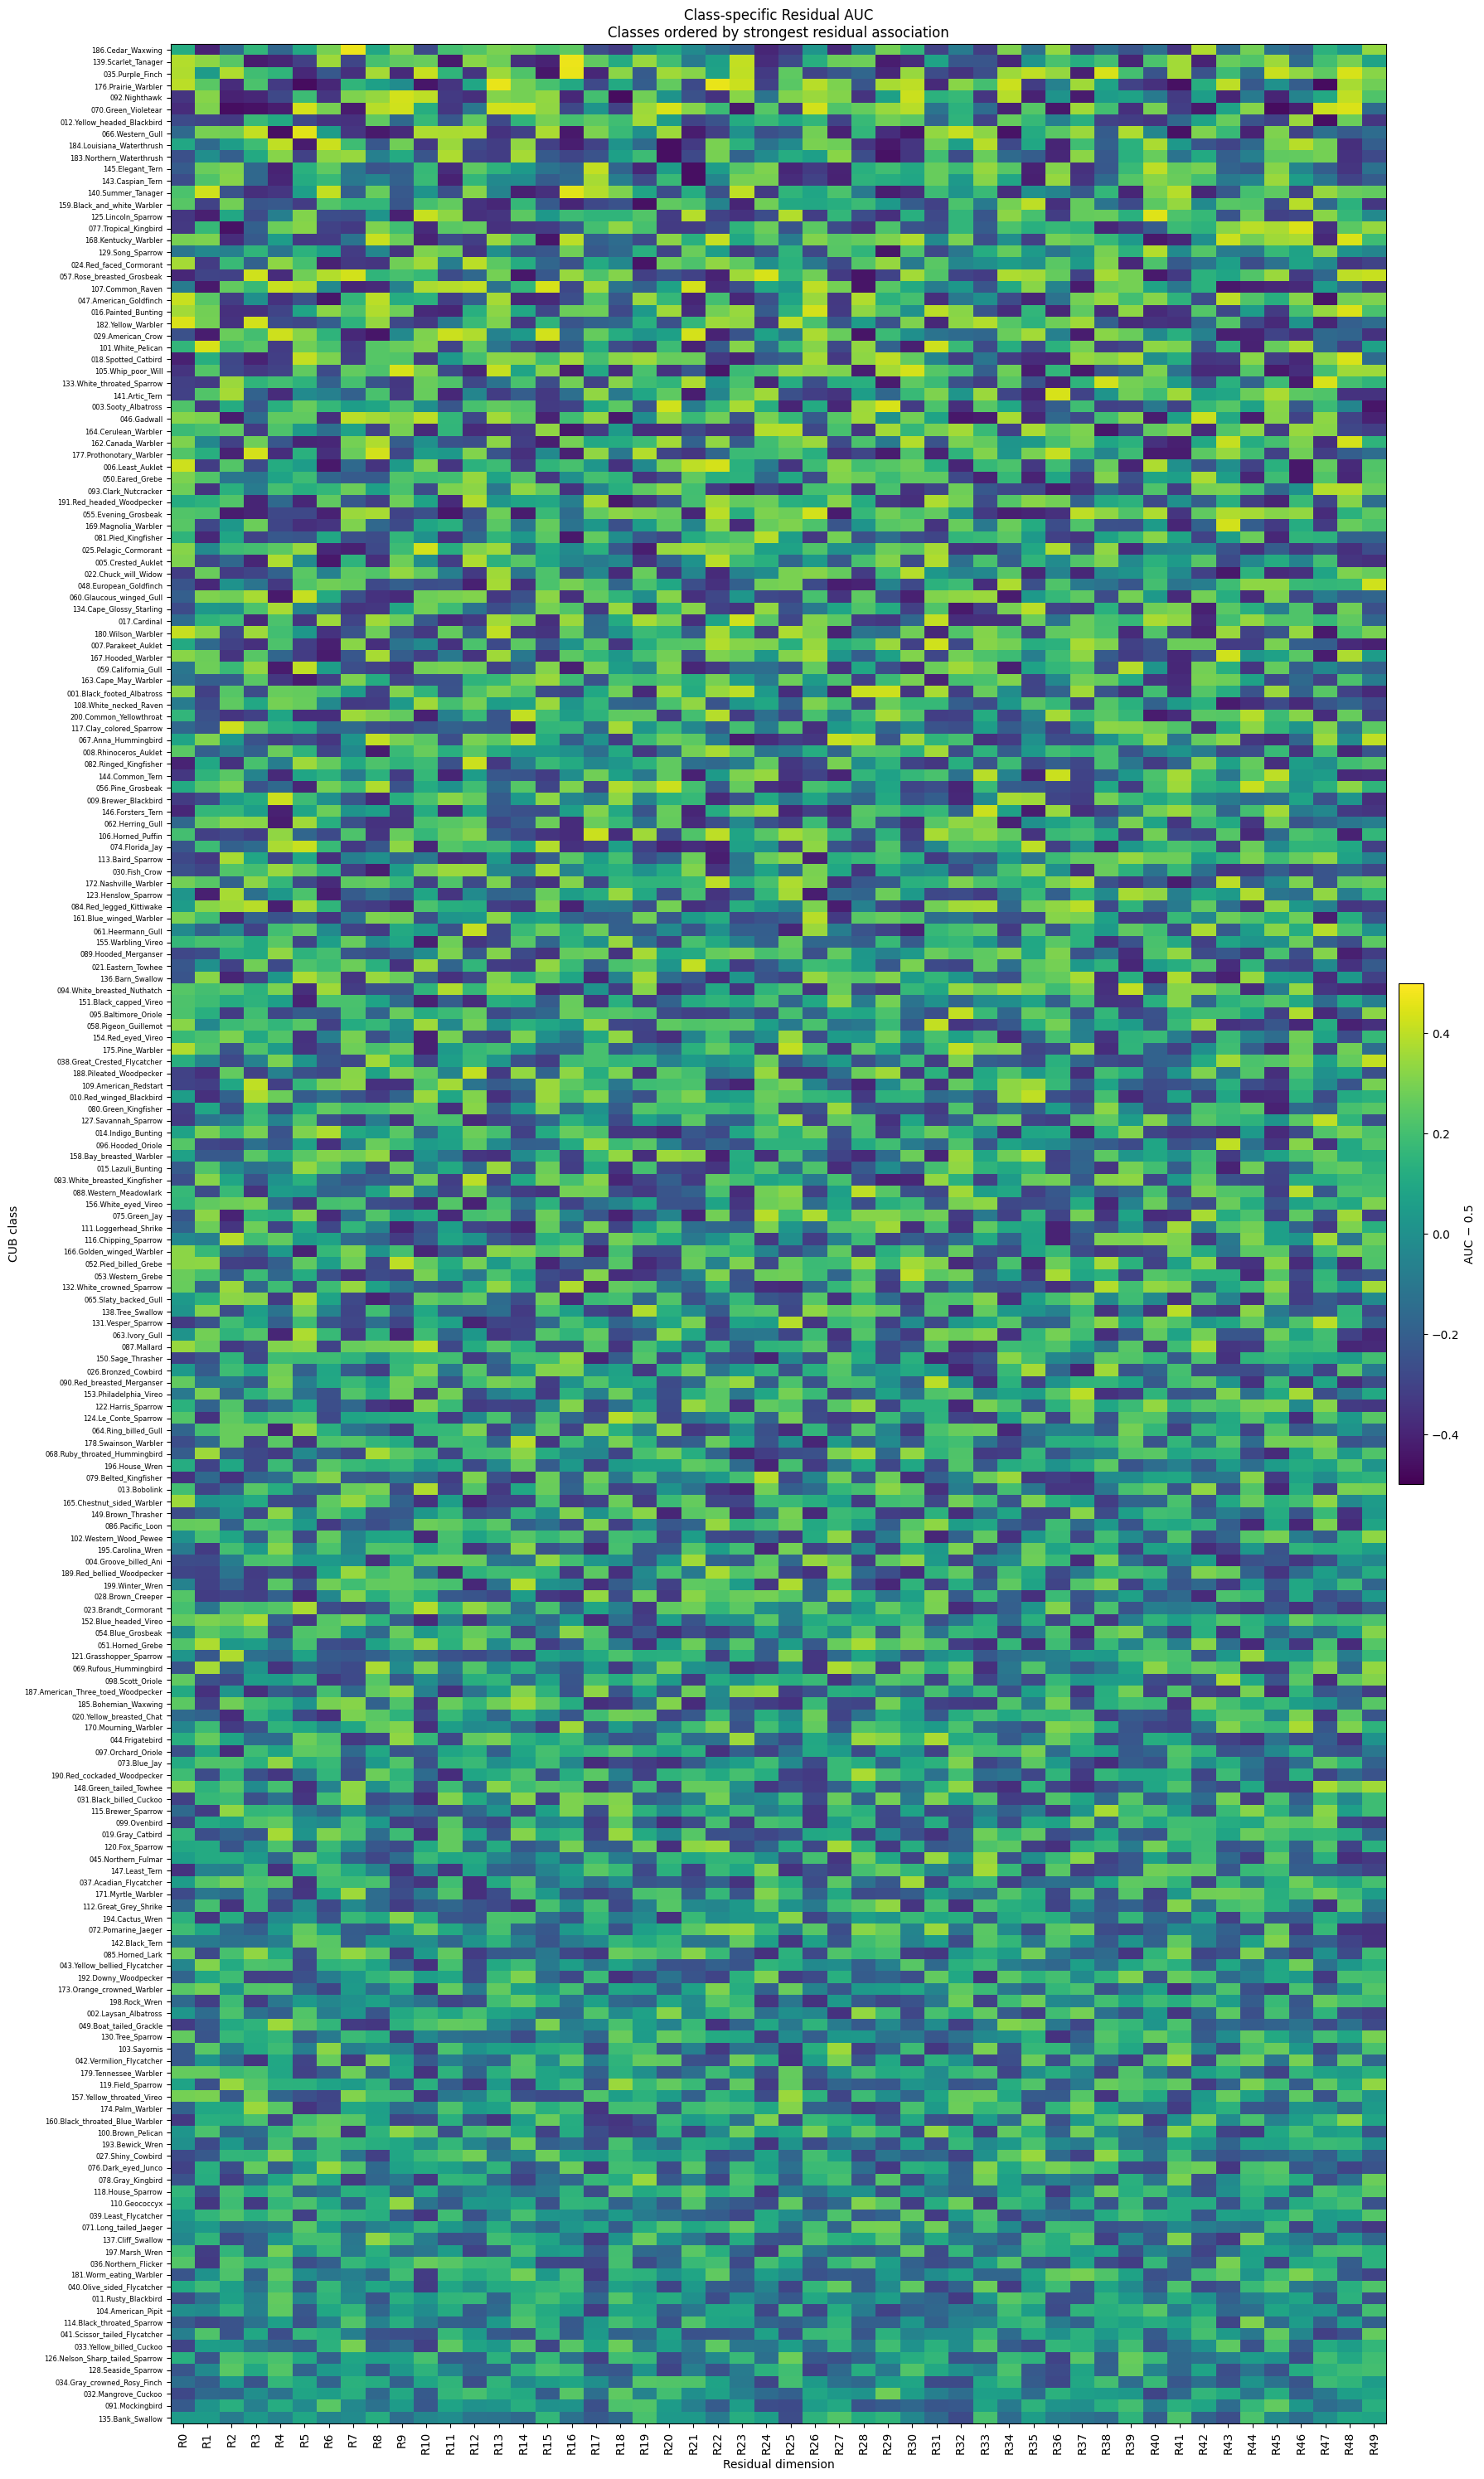

In [34]:
# ============================================================
# Sort classes by strongest residual association
# ============================================================

class_max_auc_strength = (
    auc_strength_matrix.max(axis=1)
)


class_order = np.argsort(
    class_max_auc_strength
)[::-1]


sorted_auc_direction = (
    auc_direction_matrix[
        class_order,
        :
    ]
)

sorted_class_names = [
    class_names_names[i]
    for i in class_order
]


fig, ax = plt.subplots(
    figsize=(18, 30)
)


im = ax.imshow(
    sorted_auc_direction,
    aspect="auto",
    interpolation="nearest",
    vmin=-0.5,
    vmax=0.5,
)


ax.set_xticks(
    np.arange(R)
)

ax.set_xticklabels(
    [
        f"R{j}"
        for j in range(R)
    ],
    rotation=90,
)


ax.set_yticks(
    np.arange(num_classes)
)

ax.set_yticklabels(
    sorted_class_names,
    fontsize=6,
)


ax.set_xlabel(
    "Residual dimension"
)

ax.set_ylabel(
    "CUB class"
)

ax.set_title(
    "Class-specific Residual AUC\n"
    "Classes ordered by strongest residual association"
)


cbar = fig.colorbar(
    im,
    ax=ax,
    fraction=0.02,
    pad=0.01,
)

cbar.set_label(
    "AUC − 0.5"
)


plt.tight_layout()
plt.show()

In [35]:
# ============================================================
# Top residuals for each class by AUC strength
# ============================================================

TOP_N = 5

top_residuals_by_class = []


for class_idx in range(num_classes):

    strengths = auc_strength_matrix[
        class_idx
    ]

    top_indices = np.argsort(
        strengths
    )[::-1][:TOP_N]


    for rank, residual_idx in enumerate(
        top_indices,
        start=1,
    ):

        auc = auc_matrix[
            class_idx,
            residual_idx
        ]

        top_residuals_by_class.append(
            {
                "class_idx":
                    class_idx,

                "class_name":
                    class_names_names[
                        class_idx
                    ],

                "rank":
                    rank,

                "residual_idx":
                    residual_idx,

                "auc":
                    auc,

                "auc_direction":
                    auc - 0.5,

                "auc_strength":
                    abs(auc - 0.5),
            }
        )


top_residuals_by_class_df = (
    pd.DataFrame(
        top_residuals_by_class
    )
)


display(
    top_residuals_by_class_df.head(50)
)

,class_idx,class_name,rank,residual_idx,auc,auc_direction,auc_strength
0,0,001.Black_footed_Albatross,1,29,0.923583159843,0.423583159843,0.423583159843
1,0,001.Black_footed_Albatross,2,28,0.918063266250,0.418063266250,0.418063266250
2,0,001.Black_footed_Albatross,3,27,0.096524404349,-0.403475595651,0.403475595651
3,0,001.Black_footed_Albatross,4,23,0.896709461022,0.396709461022,0.396709461022
4,0,001.Black_footed_Albatross,5,49,0.117537011335,-0.382462988665,0.382462988665
5,1,002.Laysan_Albatross,1,27,0.144968771686,-0.355031228314,0.355031228314
6,1,002.Laysan_Albatross,2,41,0.157509252834,-0.342490747166,0.342490747166
7,1,002.Laysan_Albatross,3,28,0.839547189452,0.339547189452,0.339547189452
8,1,002.Laysan_Albatross,4,20,0.819098427018,0.319098427018,0.319098427018
9,1,002.Laysan_Albatross,5,35,0.187092297016,-0.312907702984,0.312907702984


## AUC and top 5 frequency match